In [1]:
import data_preparation
import models
import hydra 
from hydra import compose, initialize
import torch 
import matplotlib.pyplot as plt 
from tqdm import tqdm

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [2]:
initialize(version_base=None, config_path="../config")
cfg = compose(config_name="train_general.yaml", overrides=['dataset=climsim_from_npy_non_stacked', 'model=squeezeformer', 'testing=qt'])
print(cfg.dataset)
print(cfg.model)


{'dataset_name': 'climsim_from_npy_non_stacked', 'input_dim': 94, 'output_dim': 98, 'levels': 45, 'normalize': True, 'target_group': '${target_group}', 'path_to_grid_info': '/home/users/bradlesc/projects/ClimSim/grid_info/ClimSim_low-res_grid-info.nc', 'data_dir': '/work/scratch-pw5/bradlesc/climsim/processed/seasons_non_stacked/', 'input_file': 'input.npy', 'target_file': 'target.npy', 'output_scale_file_path': '/home/users/bradlesc/projects/ClimSim/preprocessing/normalizations/outputs/output_scale.nc', 'v1_targets': ['ptend_t', 'ptend_q0001', 'cam_out_NETSW', 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD'], 'split': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'dataset_testing_sample_rates': {'quick': 10000, 'reduced': 100, 'full': 7}, 'group_method': 'group_by_months', 'group_by_months': {'num_groups': 4, 'target_group': '${target_group}', 'groups': {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}, 'test_group': {'JJA': N

# P2.1.4.9: A Performance Analysis 

The purpose of this notebook, is to develope a bunch of ways to have further intuition into why the models fail to perform equally well across my different groupings. It's likely due to seeing values that it has not seen before but it would be good to understand exactly where and why.

We start by looking at the sota squeezeformer and just understanding how the distribution of errors varies for different groupings. This particular squeezeformer was trained on the non-stacked dataset with the MAM group and tested on the JJA 

For now we are working with the dr options, which does mean we are not exactly looking at the correct data, but hopefully itll give an initial intuition/testing platform before we scale 

In [3]:
path_to_model = '/home/users/bradlesc/projects/ClimSim/logs/p2.1.4/7/squeeze_former_group_MAM_2025-12-29-09-41-08/squeezeformer_group_MAM/squeezeformer_None_2025-12-29-09-41-08.ckpt'

In [4]:
# Model
model = models.load_model_from_checkpoint(path_to_model, cfg.model.name, cfg.model.single_run_configuration, cfg.dataset)

2026-01-02 09:12:51,002 - INFO - Initializing SqueezeFormer with in_dim=6, embed_dim=256, out_dim=10


In [5]:
# Datasets

# MAM 'in distribution' training set 
cfg.dataset.group_by_months.target_group = 'MAM'
mam_trainset = data_preparation.ClimSimNpyDatasetNonStacked(cfg.dataset, cfg.testing.dataset_testing_type, 'train', normalisation_stats=None, model=cfg.model.name, seed=0)
mam_trainloader = torch.utils.data.DataLoader(mam_trainset, batch_size=1024, shuffle=False)
normalisation_stats = mam_trainset.normalisation_stats
logging.info('---')

# MAM 'in distribution' test set
cfg.dataset.group_by_months.test_group = {'MAM': []}
mam_testset = data_preparation.ClimSimNpyDatasetNonStacked(cfg.dataset, cfg.testing.dataset_testing_type, 'test', normalisation_stats=normalisation_stats, model=cfg.model.name, seed=0)
mam_testloader = torch.utils.data.DataLoader(mam_testset, batch_size=1024, shuffle=False)
logging.info('---')

# JJA 'out of distribution'
cfg.dataset.group_by_months.test_group = {'JJA': []}
jja_testset = data_preparation.ClimSimNpyDatasetNonStacked(cfg.dataset, cfg.testing.dataset_testing_type, 'test', normalisation_stats=normalisation_stats, model=cfg.model.name, seed=0)
jja_testloader = torch.utils.data.DataLoader(jja_testset, batch_size=1024, shuffle=False)

dataloaders = {
    'MAM_train': mam_trainloader,
    'MAM_test': mam_testloader,
    'JJA_test': jja_testloader
}

2026-01-02 09:12:52,592 - INFO - Building dataset for group: MAM
2026-01-02 09:12:52,593 - INFO - Using sample rate directory: sample_rate_10000
2026-01-02 09:12:52,743 - INFO - Loaded input shape: (6, 384, 94)
2026-01-02 09:12:52,744 - INFO - Loaded target shape: (6, 384, 98)
2026-01-02 09:12:52,744 - INFO - Using: train with 4 samples
2026-01-02 09:12:52,745 - INFO - Calculating normalization statistics from data.
2026-01-02 09:12:52,817 - INFO - Converted input shape: torch.Size([1536, 45, 6])
2026-01-02 09:12:52,821 - INFO - ---
2026-01-02 09:12:52,823 - INFO - Building dataset for group: MAM
2026-01-02 09:12:52,823 - INFO - Using sample rate directory: sample_rate_10000
2026-01-02 09:12:52,827 - INFO - Loaded input shape: (6, 384, 94)
2026-01-02 09:12:52,827 - INFO - Loaded target shape: (6, 384, 98)
2026-01-02 09:12:52,828 - INFO - Using: test with 2 samples
2026-01-02 09:12:52,828 - INFO - Using provided normalization statistics.
2026-01-02 09:12:52,872 - INFO - Converted input 

In [6]:
results = {}
for key, loader in dataloaders.items():
    logging.info(f"{key} has {len(loader.dataset)} samples.")

    predictions = []
    targets_list = []
    inputs_list = []
    with torch.no_grad():
        for batch in tqdm(loader):
            inputs, targets = batch
            outputs = model(inputs)
            predictions.append(outputs)
            targets_list.append(targets)
            inputs_list.append(inputs)

    # Analyze predictions
    predictions = torch.cat(predictions, dim=0)
    targets_all = torch.cat(targets_list, dim=0)
    inputs_all = torch.cat(inputs_list, dim=0)
    results[key] = {
        'predictions': predictions,
        'targets': targets_all,
        'inputs': inputs_all
    }
    print(f"Predictions shape: {predictions.shape}")
    print(f"Targets shape: {targets_all.shape}")

2026-01-02 09:12:53,027 - INFO - MAM_train has 1536 samples.
100%|██████████| 2/2 [00:09<00:00,  4.56s/it]
2026-01-02 09:13:02,155 - INFO - MAM_test has 768 samples.


Predictions shape: torch.Size([1536, 98])
Targets shape: torch.Size([1536, 98])


100%|██████████| 1/1 [00:04<00:00,  4.06s/it]
2026-01-02 09:13:06,215 - INFO - JJA_test has 768 samples.


Predictions shape: torch.Size([768, 98])
Targets shape: torch.Size([768, 98])


100%|██████████| 1/1 [00:04<00:00,  4.71s/it]

Predictions shape: torch.Size([768, 98])
Targets shape: torch.Size([768, 98])


Great, weve got some data to play with now that is hopefully at least a little bit representative of our scenario. Lets start with high level metrics, see if they make much sense, I think MSE here gives an approximate reading of the scenario but nothing incredibly accurate.

In [7]:
# Overall results
for key in results:
    preds = results[key]['predictions']
    targs = results[key]['targets']
    mse = torch.mean((preds - targs) ** 2).item()
    logging.info(f"{key} MSE: {mse:.4f}")

2026-01-02 09:13:10,960 - INFO - MAM_train MSE: 0.0062
2026-01-02 09:13:10,968 - INFO - MAM_test MSE: 0.0059
2026-01-02 09:13:10,969 - INFO - JJA_test MSE: 0.0064


Great, this is along the lines of what I would expect, now lets look per variable

(98,)
(98,)
(98,)


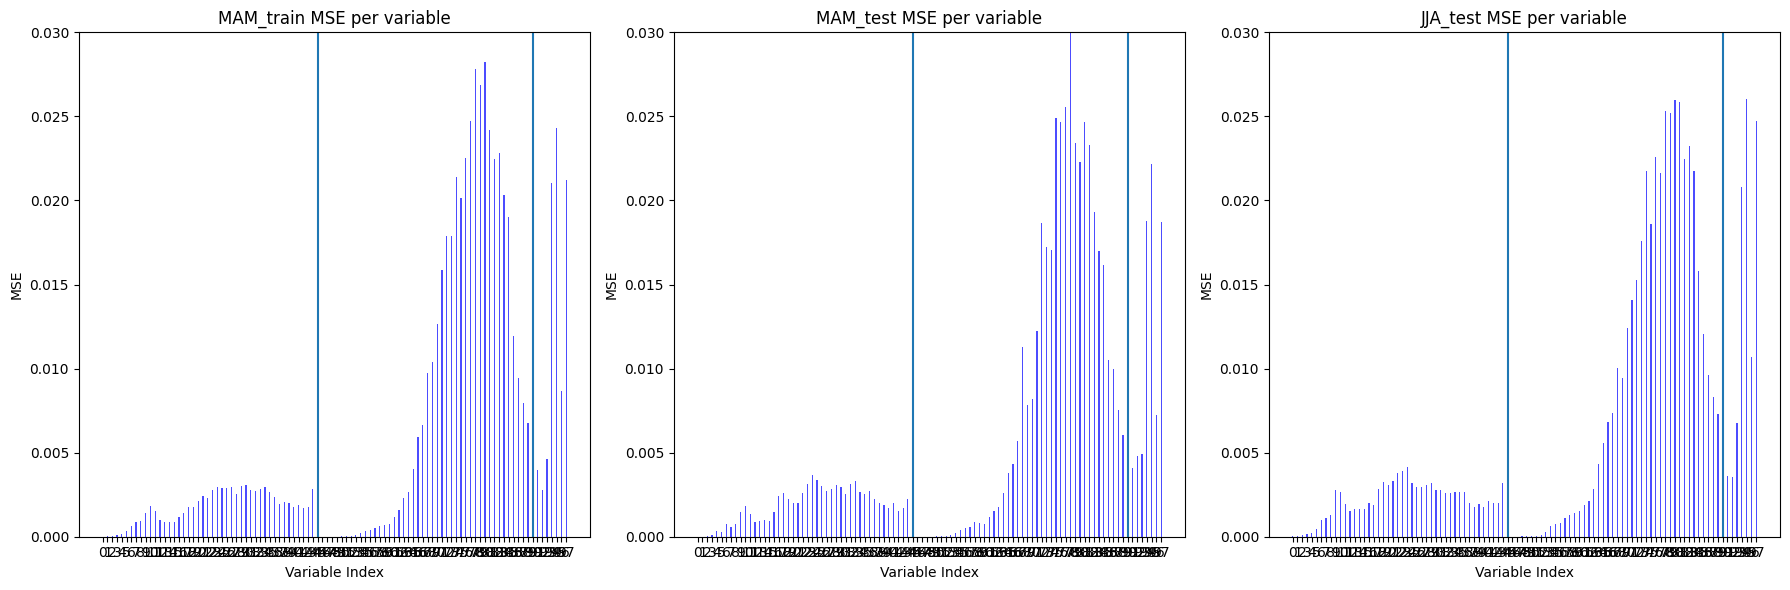

In [8]:

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
nvar = results['MAM_train']['predictions'].shape[1]
vmin = 0.0
vmax = 0.03
bar_locations = torch.arange(nvar)
width = 0.25
for i, key in enumerate(results):
    preds = results[key]['predictions']
    targs = results[key]['targets']
    mse_per_var = torch.mean((preds - targs) ** 2, dim=0).cpu().numpy()
    print(mse_per_var.shape)
    axs[i].bar(bar_locations, mse_per_var, width=width, color='b', alpha=0.7)
    axs[i].set_title(f"{key} MSE per variable")
    axs[i].set_xlabel("Variable Index")
    axs[i].set_ylabel("MSE")
    axs[i].set_xticks(bar_locations)
    axs[i].set_ylim(vmin, vmax)
    axs[i].axvline(x=45)
    axs[i].axvline(x=90)

plt.tight_layout()

So it looks like the shape of the errors across all are approximately the same with low altitude air temp carruing a lrge amount of error and the fluxes as well. It is hard to see where JJA is doing worse, so lets look at a per variable MSE comparison

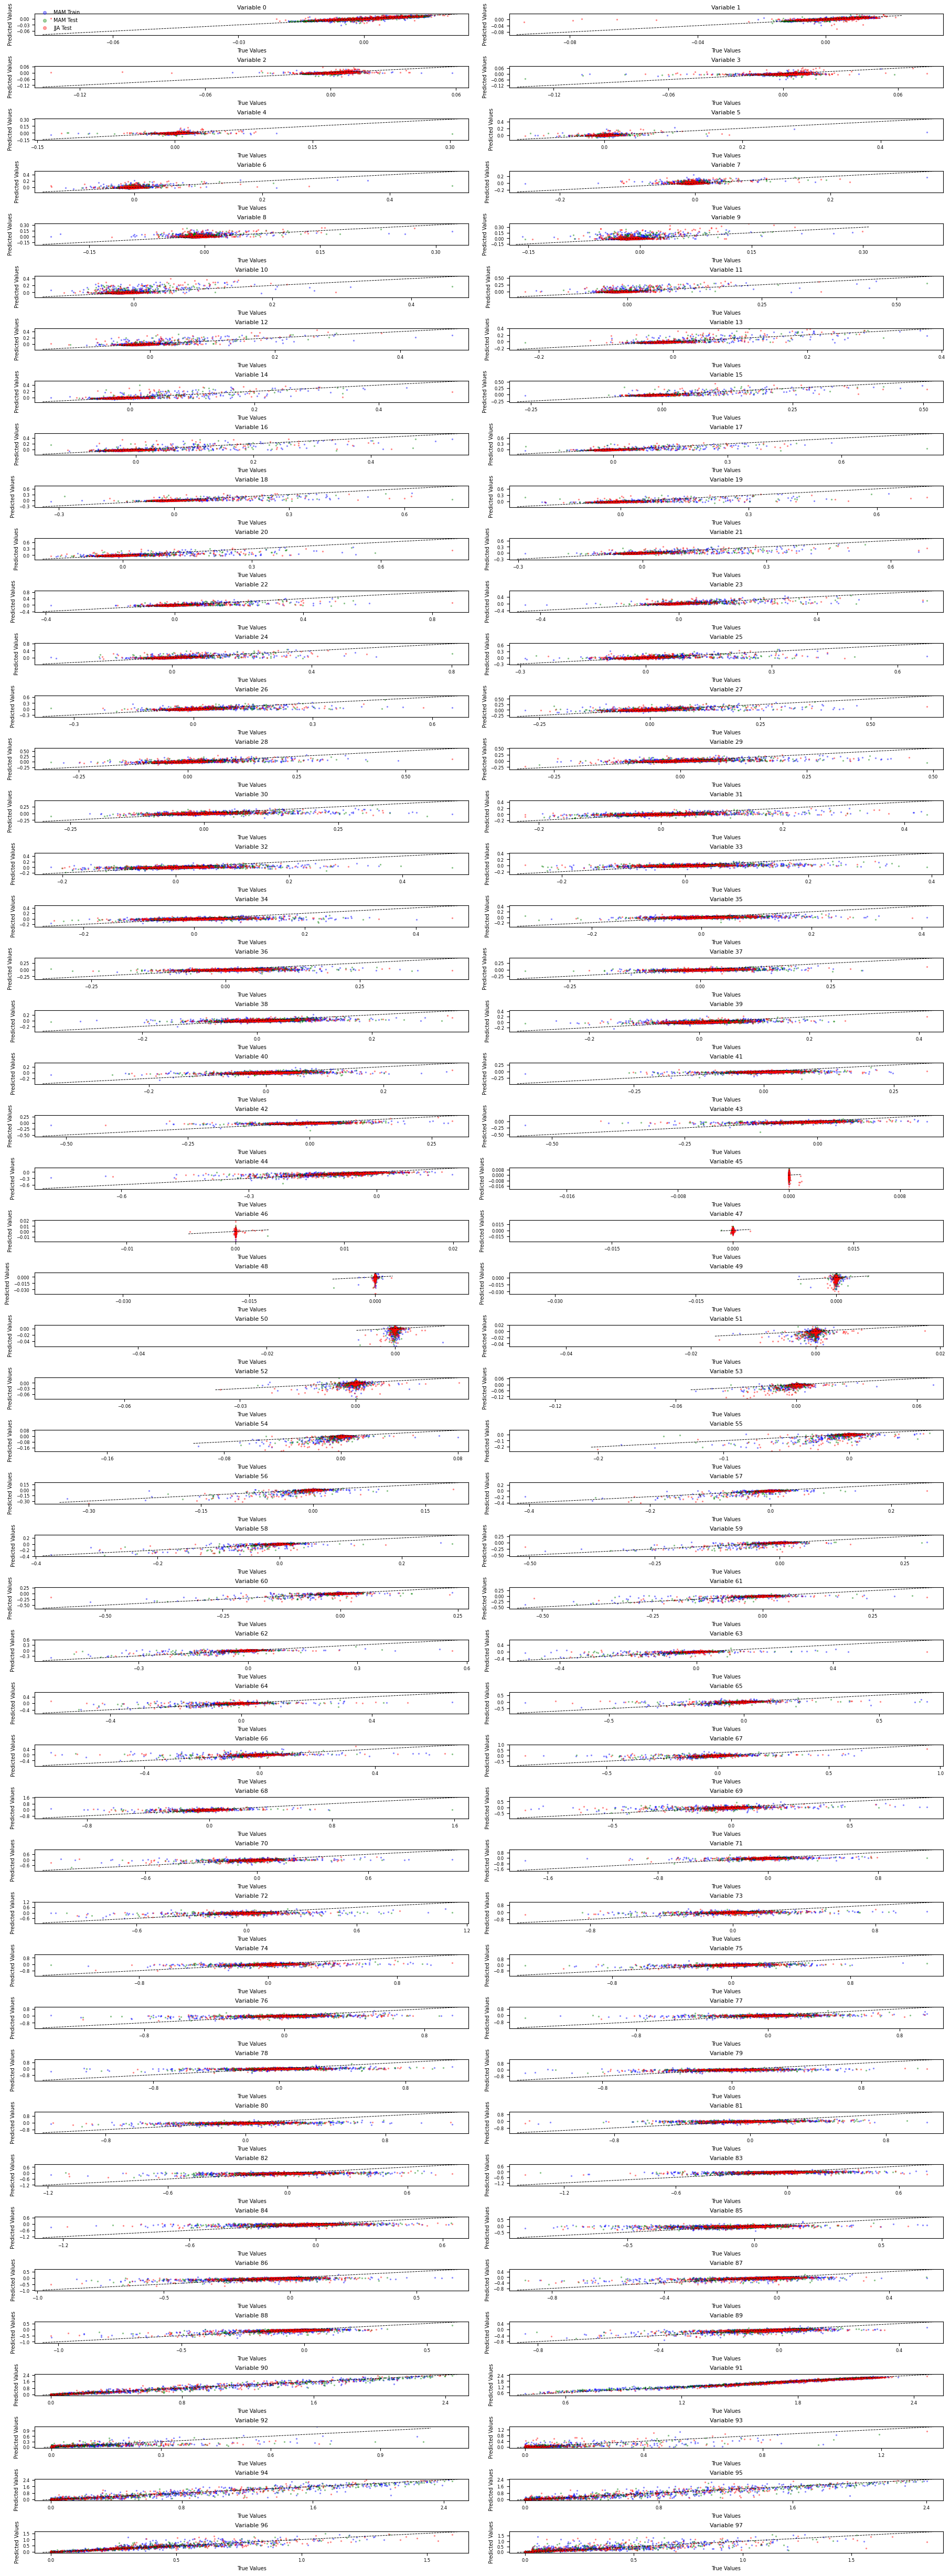

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

n_vars = 98
n_rows = n_vars // 2  # 49
n_cols = 2

# choose a reasonable height per row (e.g. 0.35-0.6); tweak to taste
height_per_row = 1
figsize = (18, n_rows * height_per_row)

fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=True)
axs = np.atleast_2d(axs)  # ensure indexing works even if shape odd

# plotting appearance
marker_size = 2
alpha = 0.35
title_fontsize = 8
label_fontsize = 7
tick_fontsize = 6

for var_idx in range(n_vars):
    ax_row = var_idx // n_cols
    ax_col = var_idx % n_cols
    ax = axs[ax_row, ax_col]

    # load arrays (convert to 1D numpy arrays)
    preds_mam_train = results['MAM_train']['predictions'][:, var_idx].cpu().numpy()
    targs_mam_train = results['MAM_train']['targets'][:, var_idx].cpu().numpy()

    preds_mam_test = results['MAM_test']['predictions'][:, var_idx].cpu().numpy()
    targs_mam_test = results['MAM_test']['targets'][:, var_idx].cpu().numpy()

    preds_jja_test = results['JJA_test']['predictions'][:, var_idx].cpu().numpy()
    targs_jja_test = results['JJA_test']['targets'][:, var_idx].cpu().numpy()

    # scatter
    if targs_mam_train.size:
        ax.scatter(targs_mam_train, preds_mam_train, alpha=alpha, s=marker_size, label='MAM Train', color='blue')
    if targs_mam_test.size:
        ax.scatter(targs_mam_test, preds_mam_test, alpha=alpha, s=marker_size, label='MAM Test', color='green')
    if targs_jja_test.size:
        ax.scatter(targs_jja_test, preds_jja_test, alpha=alpha, s=marker_size, label='JJA Test', color='red')

    # determine a sensible diagonal range from all true values available for this var
    all_targs = np.concatenate([a for a in (targs_mam_train, targs_mam_test, targs_jja_test) if a.size > 0])
    if all_targs.size:
        vmin, vmax = float(all_targs.min()), float(all_targs.max())
        pad = 0.02 * (vmax - vmin) if (vmax > vmin) else 0.1
        lo, hi = vmin - pad, vmax + pad
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
        ax.set_xlim(lo, hi)
        # for predicted values try to set limits from predictions too (keep aspect)
        all_preds = np.concatenate([a for a in (preds_mam_train, preds_mam_test, preds_jja_test) if a.size > 0])
        if all_preds.size:
            pmin, pmax = float(all_preds.min()), float(all_preds.max())
            # combine ranges
            combined_lo = min(lo, pmin) - pad
            combined_hi = max(hi, pmax) + pad
            ax.set_xlim(combined_lo, combined_hi)
            ax.set_ylim(combined_lo, combined_hi)
    # labels & title with small fonts
    ax.set_title(f'Variable {var_idx}', fontsize=title_fontsize)
    ax.set_xlabel('True Values', fontsize=label_fontsize)
    ax.set_ylabel('Predicted Values', fontsize=label_fontsize)

    # reduce number of ticks to avoid overlap
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# Put a single legend in the very first subplot (0,0)
axs[0,0].legend(fontsize=7, markerscale=3, frameon=False)

# If odd number of subplots (not in this case) you might want to hide the unused axes:
# for idx in range(n_vars, n_rows*n_cols):
#     r, c = divmod(idx, n_cols)
#     axs[r, c].axis('off')

# optionally save (uncomment to write file)
# fig.savefig('/mnt/data/fixed_scatter_grid.png', dpi=150, bbox_inches='tight')

plt.show()



Cheers gpt, this is good and all, but its not giving me details on where JJA is worse! And thats what we want to find out

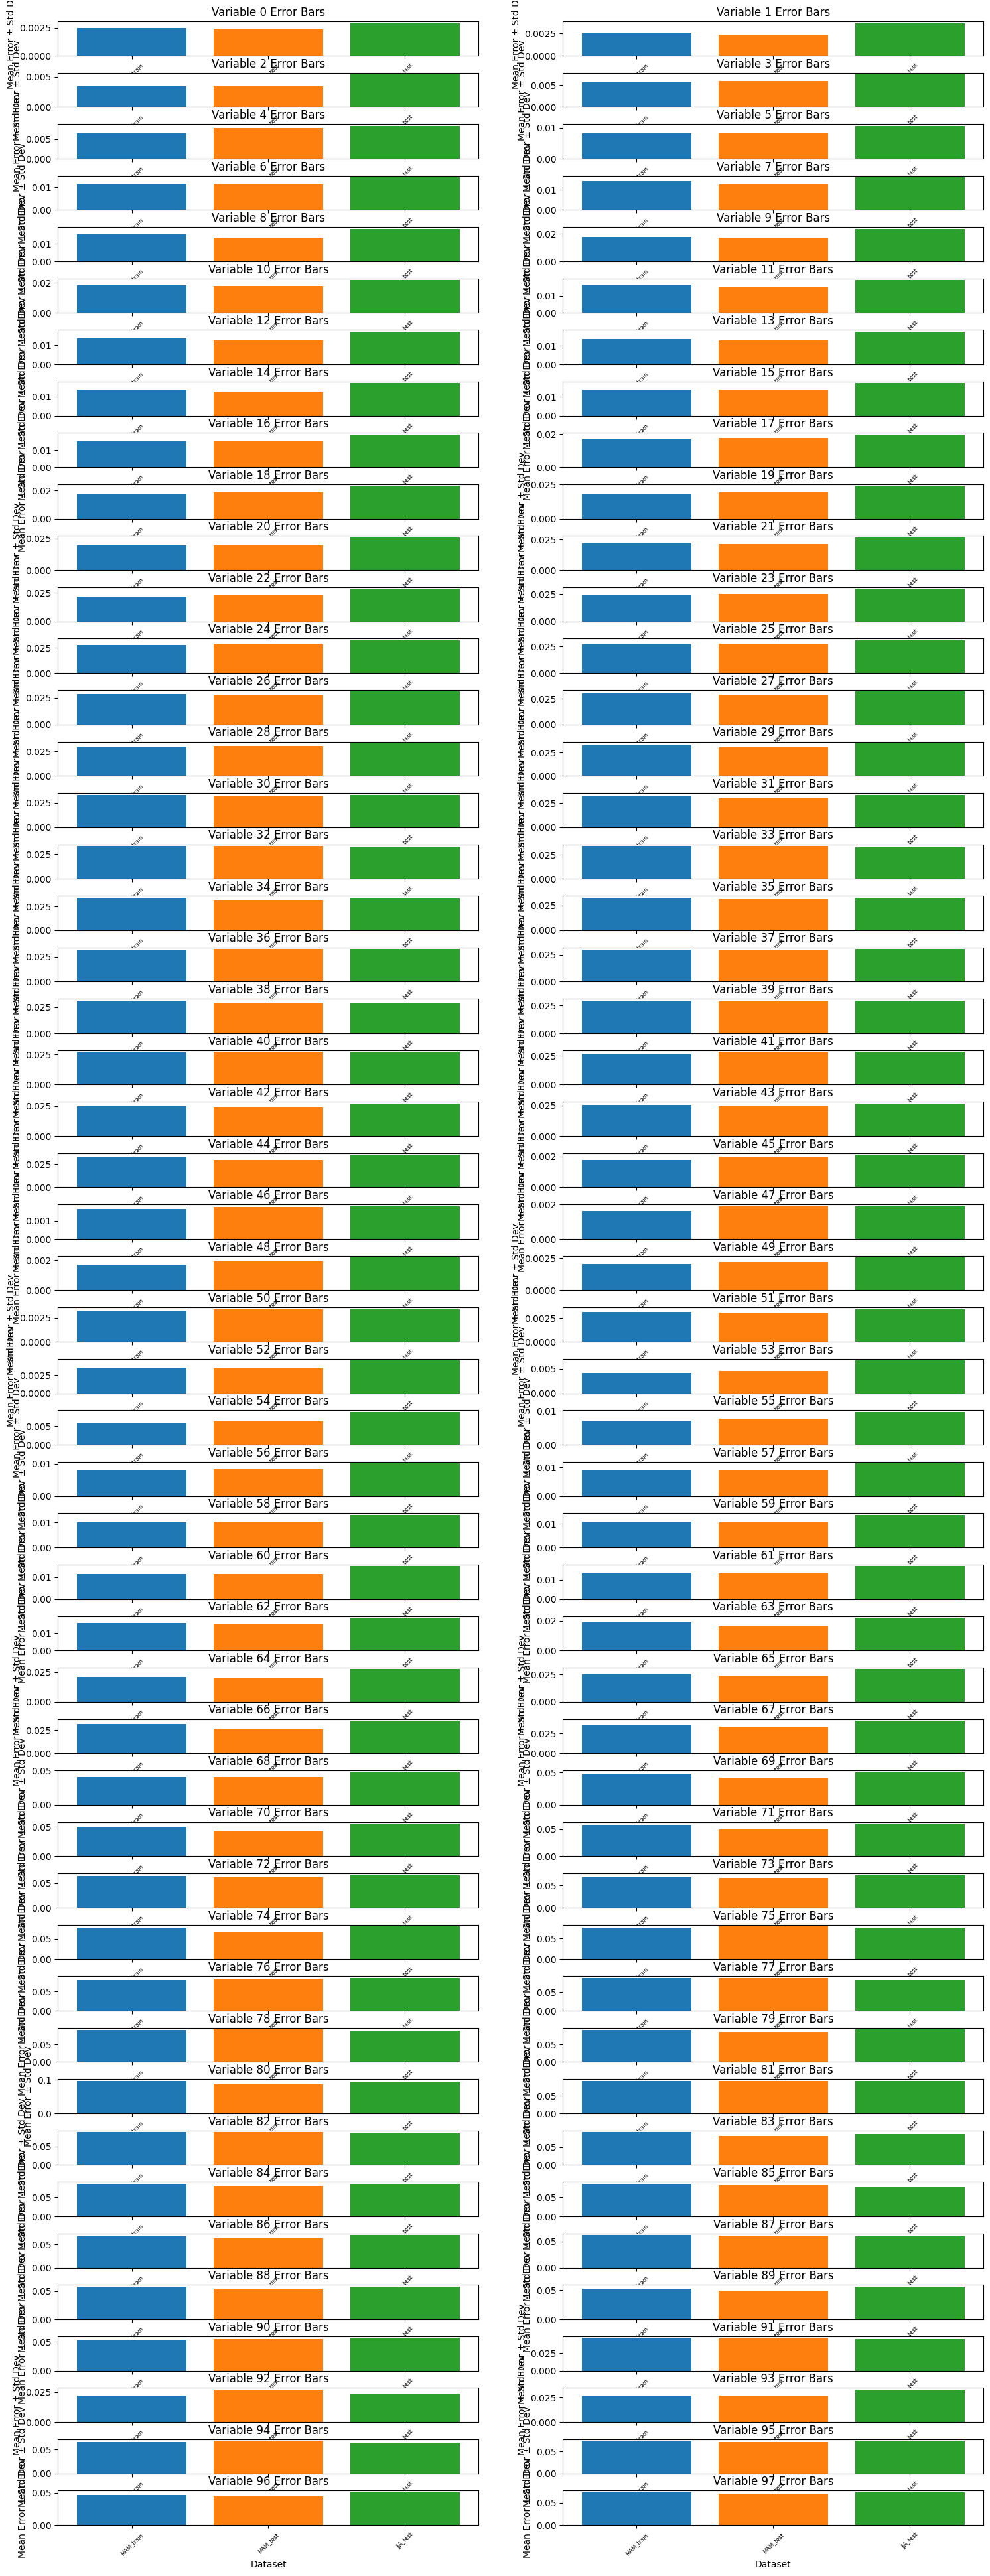

In [10]:
fig, axes = plt.subplots(nrows=49, ncols=2, figsize=(18, 49))
row_space = 0.5
fig.subplots_adjust(hspace=row_space)
axes = axes.flatten()
for var_idx in range(98):
    for i, key in enumerate(results):
        preds = results[key]['predictions'][:, var_idx].cpu().numpy()
        targs = results[key]['targets'][:, var_idx].cpu().numpy()
        errors = np.abs(preds - targs)
        axes[var_idx].bar(i, np.mean(errors), label=key)
    axes[var_idx].set_title(f'Variable {var_idx} Error Bars')
    axes[var_idx].set_xlabel('Dataset')
    axes[var_idx].set_ylabel('Mean Error ± Std Dev')
    axes[var_idx].set_xticks(range(len(results)))
    axes[var_idx].set_xticklabels(list(results.keys()), rotation=45, fontsize=6)

plt.show()


Interesting, it does just seem that the error is slightly more for the majority, I think perhaps it doesnt actually align with the variable error plots, lets look at a more quantitive split of which are most effected.

torch.Size([98])


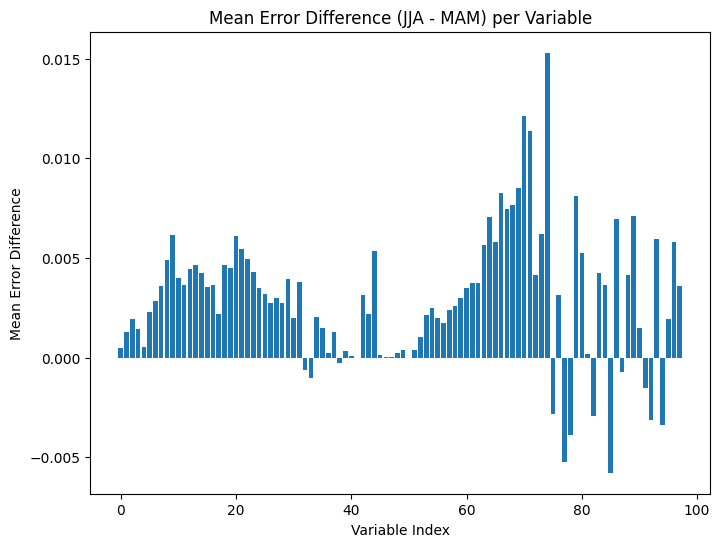

(98,)
(98,)


(98,)


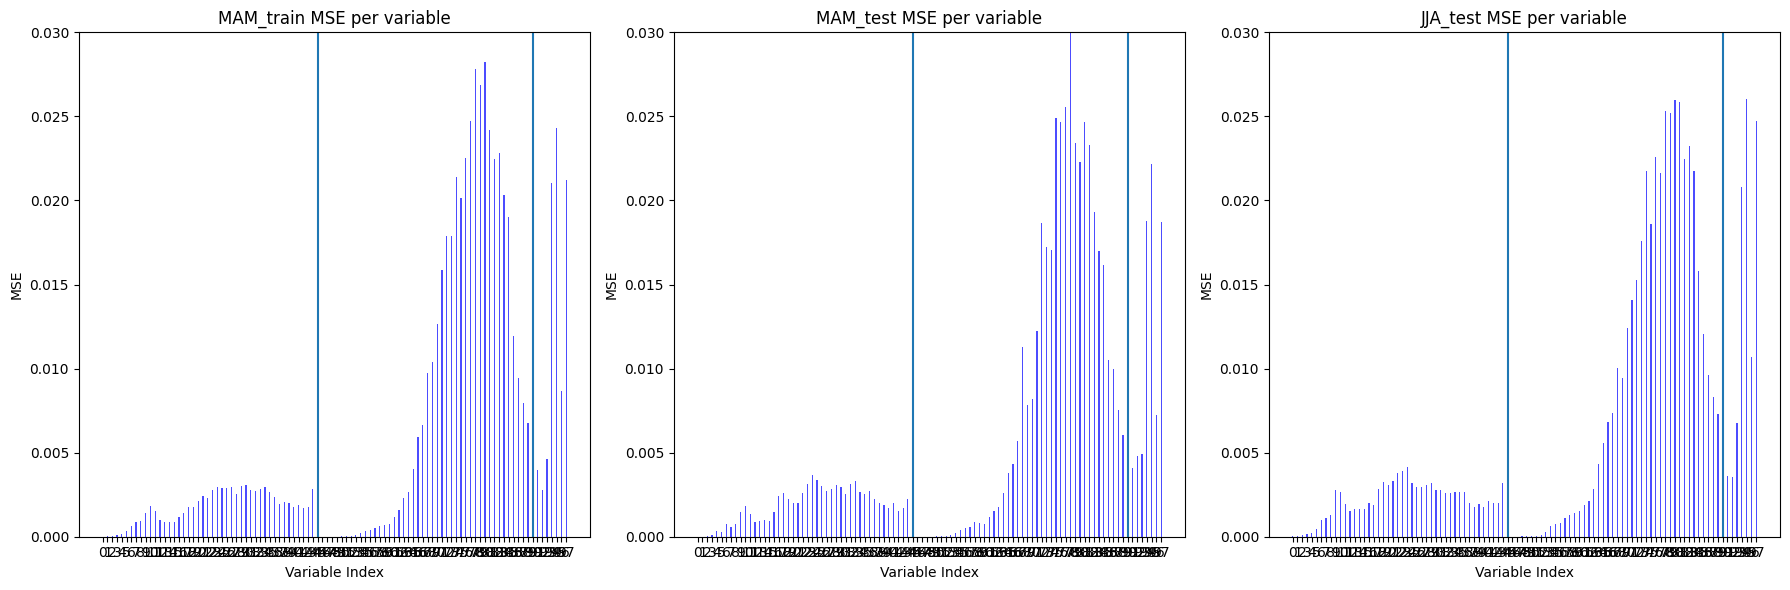

In [11]:
mam_test = results['MAM_test']
jja_test = results['JJA_test']

mam_error = torch.abs(mam_test['predictions'] - mam_test['targets']).mean(dim=0)
jja_error = torch.abs(jja_test['predictions'] - jja_test['targets']).mean(dim=0)
error_difference = jja_error - mam_error  # Positive values indicate higher error in JJA
print(error_difference.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(range(error_difference.shape[0]), error_difference.cpu().numpy())
ax.set_title('Mean Error Difference (JJA - MAM) per Variable')
ax.set_xlabel('Variable Index')
ax.set_ylabel('Mean Error Difference')
plt.show()


fig, axs = plt.subplots(1, 3, figsize=(18, 6))
nvar = results['MAM_train']['predictions'].shape[1]
vmin = 0.0
vmax = 0.03
bar_locations = torch.arange(nvar)
width = 0.25
for i, key in enumerate(results):
    preds = results[key]['predictions']
    targs = results[key]['targets']
    mse_per_var = torch.mean((preds - targs) ** 2, dim=0).cpu().numpy()
    print(mse_per_var.shape)
    axs[i].bar(bar_locations, mse_per_var, width=width, color='b', alpha=0.7)
    axs[i].set_title(f"{key} MSE per variable")
    axs[i].set_xlabel("Variable Index")
    axs[i].set_ylabel("MSE")
    axs[i].set_xticks(bar_locations)
    axs[i].set_ylim(vmin, vmax)
    axs[i].axvline(x=45)
    axs[i].axvline(x=90)

plt.tight_layout()
plt.show()

Ok so it actually aligns more with the structure than I thought - we are seeing values that give more error accross the board, be (mostly) worse for specific variables, lets take the scatter plot and look in more detail at the top 4.

tensor([74, 70, 71, 69, 66, 79, 68, 67, 89, 64, 86, 73,  9, 20, 93, 65, 96, 63,
        21, 44, 80, 22,  8, 18, 13, 19, 12, 23, 14, 83, 72, 88, 10, 29, 31, 62,
        61, 11, 16, 84,  7, 97, 15, 60, 24, 25, 76, 42, 59, 27,  6, 28, 26, 58,
        54, 57,  5, 17, 43, 53, 34, 55, 30,  2, 95, 56, 35, 90,  3, 37,  1, 52,
         4,  0, 51, 49, 39, 48, 36, 81, 45, 40, 46, 47, 41, 50, 38, 32, 87, 33,
        91, 75, 82, 92, 94, 78, 77, 85])
tensor([ 1.5300e-02,  1.2127e-02,  1.1394e-02,  8.5210e-03,  8.2762e-03,
         8.0933e-03,  7.6451e-03,  7.4550e-03,  7.0857e-03,  7.0336e-03,
         6.9407e-03,  6.1969e-03,  6.1430e-03,  6.1164e-03,  5.9713e-03,
         5.7859e-03,  5.7825e-03,  5.6406e-03,  5.4260e-03,  5.3436e-03,
         5.2350e-03,  4.9601e-03,  4.8842e-03,  4.6620e-03,  4.6467e-03,
         4.4856e-03,  4.4409e-03,  4.2916e-03,  4.2514e-03,  4.2450e-03,
         4.1329e-03,  4.1313e-03,  4.0101e-03,  3.9317e-03,  3.8134e-03,
         3.7609e-03,  3.7519e-03,  3.6511e-03,  

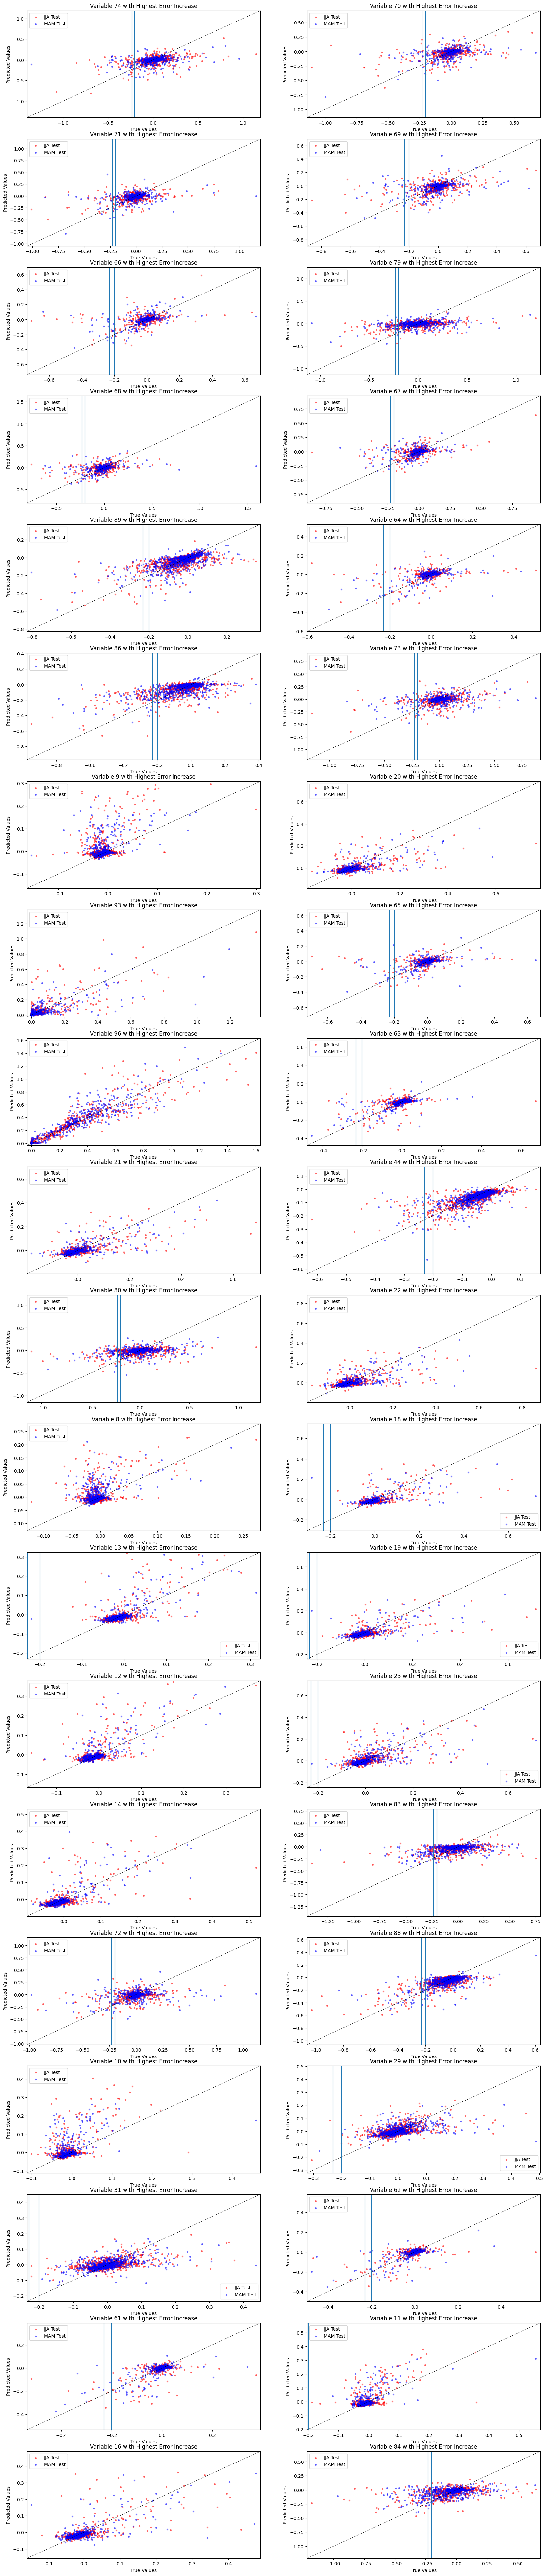

In [12]:
sorted_error_differences_indeces = torch.argsort(error_difference, descending=True)
print(sorted_error_differences_indeces)
print(error_difference[sorted_error_differences_indeces])

top_lot_to_show = 40
fig, axes = plt.subplots(top_lot_to_show // 2, 2, figsize=(20, 100))
for i in range(top_lot_to_show):
    var_idx = sorted_error_differences_indeces[i].item()
    preds_mam_test = results['MAM_test']['predictions'][:, var_idx].cpu().numpy()
    targs_mam_test = results['MAM_test']['targets'][:, var_idx].cpu().numpy()

    preds_jja_test = results['JJA_test']['predictions'][:, var_idx].cpu().numpy()
    targs_jja_test = results['JJA_test']['targets'][:, var_idx].cpu().numpy()

    ax = axes[i // 2, i % 2]
    ax.scatter(targs_jja_test, preds_jja_test, alpha=0.5, s=8, label='JJA Test', color='red')
    ax.scatter(targs_mam_test, preds_mam_test, alpha=0.5, s=8, label='MAM Test', color='blue')
    ax.axvline(x=-0.23)
    ax.axvline(x=-0.20)



    vmin = min(targs_mam_test.min(), targs_jja_test.min())
    vmax = max(targs_mam_test.max(), targs_jja_test.max())
    pad = 0.02 * (vmax - vmin) if (vmax > vmin) else 0.1
    lo, hi = vmin - pad, vmax + pad
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(f'Variable {var_idx} with Highest Error Increase')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    ax.legend()

Ok, what i am making of this plot, is the model is pretty terrible when it comes to mid altitudes. But there isn't noticeably significant gaps in either the values or the groupings. There is of course variation, an im sure more variation that I am noticing - but it doesnt really seem like the shift is that much. That being said, this is all outputs so far. Perhaps we have a dive to see how the input distributions are affecting the output or vice versa. I guess I am starting to see what I am looking for, we are trying to workout if I can find a location where there is clear seperation between the two datasets, i.e find a clear location where the model is failing to 'adapt'.

Looking a bit closer - it does also just kind of feel like there is more 'reds' (JJA's) that are more outliers - i.e the model has been trained on less values at those locations (further from zero). It does seem that the error causing features are the ones that are more centered around 0.

I think yes, it would be interesting to see how input values effect error - i.e is it purley just when it hasnt seen these values before?

Lets start 'simple', there is two blue points that the model seemingly captures perfectly. There is also several red points with almost the exact same true value, that the model seems to fail to predict. So the question is what is the difference between these points, and most likely the answer will be the inputs. So we want to compare these inputs. Lets select our main cause of error - number 70, which is mid to low atmosphere air temperature (I think). Lets select a slice of true values gather all the input variables for each of those points, and draw a scatter/bar kinda thing maybe color with the error of that plot.

Ok actually we are going for a slightly different plan, again starting high level and we can then dive in. So we want input variables on the x axis, and their value on the y axis as a scatter. Then we want to color the scatter by the error. and we want two plots next to each other, one for MAM and the other for JJA with the same y axis

In [13]:
def reshape_to_standard_format(x: torch.Tensor) -> torch.Tensor:
        """
        Reshapes the output to standard format (batch, variables) from (batch, levels, features)
        Args:
            x: (torch.Tensor) (batch, levels, features) output data from the model
        Returns:
            reshaped_x: (torch.Tensor) (batch, features) reshaped output data
        """

        # flatten the first two levels into (n, 120) in one op
        first_two = (
            x[:, :, 0:2].transpose(1, 2).reshape(x.shape[0], -1)
        )  # shape (n, 2*60) == (n,120)
        # first_two = first_two[
        #     :, :-15
        # ]  # HARDCODED REMOVAL OF TOP SH Levels # shape (n, 105) which is set to 0 in the input
        # compute the per-level means for levels 2..7 in one op
        means_2_to_7 = x[:, :, 2:10].mean(dim=1)  # shape (n, 6)
        # concatenate once
        output = torch.cat([first_two, means_2_to_7], dim=1)  # shape (n, 126)
        return output


torch.Size([768])
torch.Size([768, 94])


(-0.8880309462547302, 5.85391092300415)

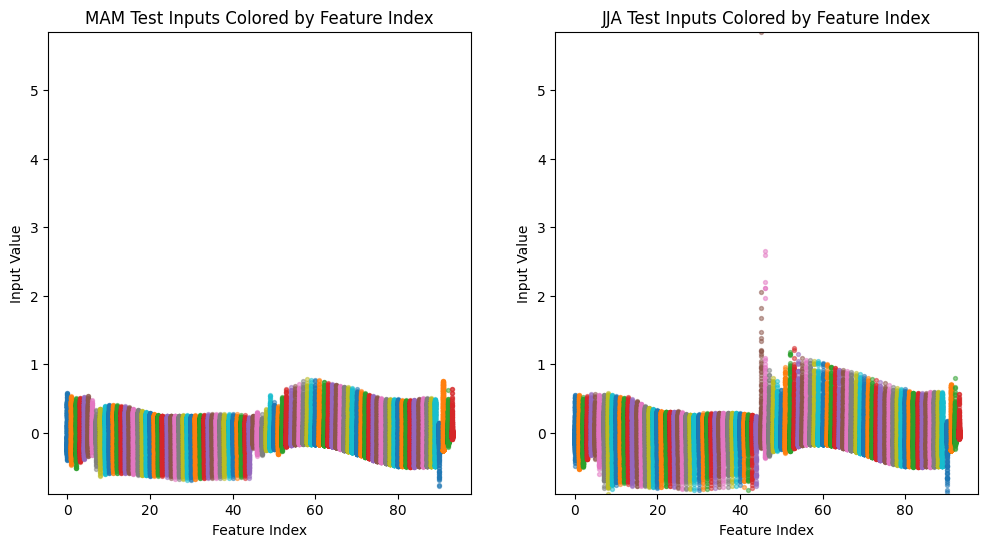

In [14]:
# Looking at inputs that cause our model to have high errors in JJA compared to MAM starting with high level case and then we can look further


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

mam_input = reshape_to_standard_format(mam_test['inputs'])
jja_input = reshape_to_standard_format(jja_test['inputs'])
vmax = torch.max(mam_input.max(), jja_input.max()).item()

vmin = torch.min(mam_input.min(), jja_input.min()).item()
# MAM first 
ax = axes[0]
error = torch.abs(mam_test['predictions'] - mam_test['targets']).mean(dim=1)
print(error.shape)
print(mam_input.shape)
for feature_idx in range(mam_input.shape[1]):
    inputs_feature = mam_input[:, feature_idx].cpu().numpy()
    x = feature_idx * np.ones_like(inputs_feature)
    ax.scatter(x, inputs_feature, alpha=0.5, s=8, label=f'Feature {feature_idx}')
ax.set_title('MAM Test Inputs Colored by Feature Index')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Input Value')
ax.set_ylim(vmin, vmax)


# JJA next
ax = axes[1]
error = torch.abs(jja_test['predictions'] - jja_test['targets']).mean(dim=1)
for feature_idx in range(jja_input.shape[1]):
    inputs_feature = jja_input[:, feature_idx].cpu().numpy()
    x = feature_idx * np.ones_like(inputs_feature)
    ax.scatter(x, inputs_feature, alpha=0.5, s=8, label=f'Feature {feature_idx}')
ax.set_title('JJA Test Inputs Colored by Feature Index')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Input Value')
ax.set_ylim(vmin, vmax)

/tmp/ipykernel_357461/646439737.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


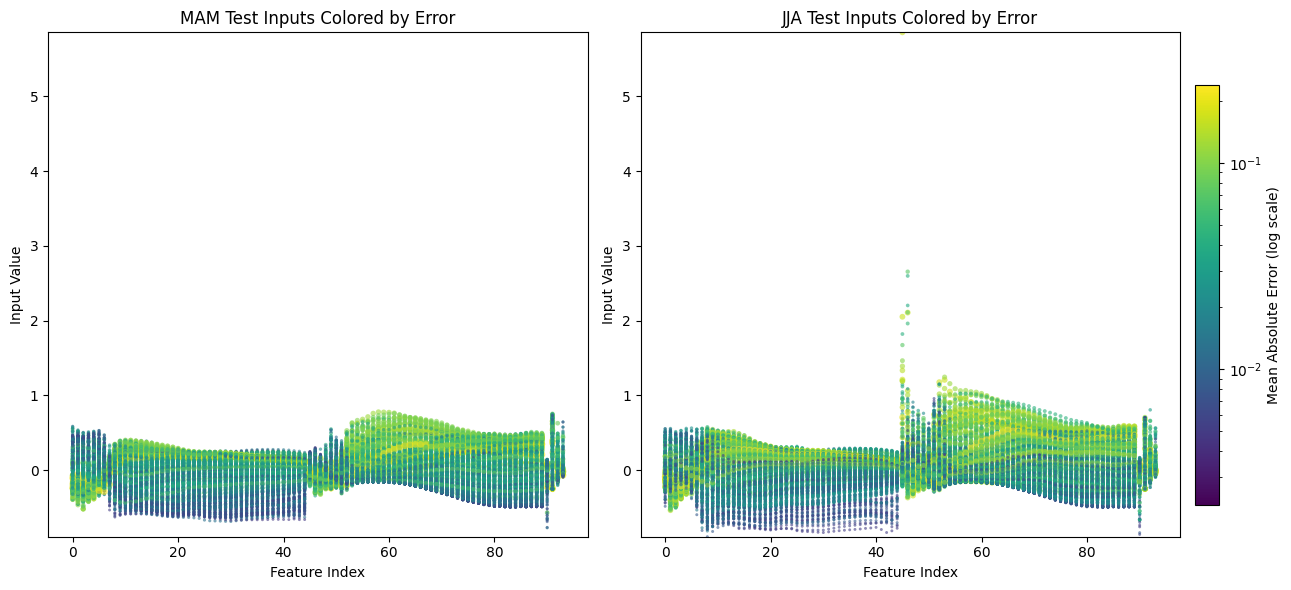

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import matplotlib as mpl

def compare_input_distributions_by_error(vmin=None, vmax=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    mam_input = reshape_to_standard_format(mam_test['inputs'])
    jja_input = reshape_to_standard_format(jja_test['inputs'])

    if vmin is None:
        vmin = torch.min(mam_input.min(), jja_input.min()).item()
    if vmax is None:
        vmax = torch.max(mam_input.max(), jja_input.max()).item()

    # --- Compute errors ---
    mam_error = torch.abs(
        mam_test['predictions'] - mam_test['targets']
    ).mean(dim=1)

    jja_error = torch.abs(
        jja_test['predictions'] - jja_test['targets']
    ).mean(dim=1)

    # --- Shared color normalization ---
    all_errors = torch.cat([mam_error, jja_error])
    norm = mpl.colors.LogNorm(
        vmin=all_errors.min().item(),
        vmax=all_errors.max().item()
    )
    cmap = plt.cm.viridis

    # Error sized points 
    # Normalize errors for size scaling
    mam_size = 4 + 20 * (
        mam_error / mam_error.max()
    ).cpu().numpy()

    jja_size = 4 + 20 * (
        jja_error / jja_error.max()
    ).cpu().numpy()

    # ======================
    # MAM plot
    # ======================
    ax = axes[0]
    for feature_idx in range(mam_input.shape[1]):
        inputs_feature = mam_input[:, feature_idx].cpu().numpy()
        x = feature_idx * np.ones_like(inputs_feature)

        sc = ax.scatter(
            x,
            inputs_feature,
            c=mam_error.cpu().numpy(),   # color by error
            cmap=cmap,
            norm=norm,
            alpha=0.6,
            s=mam_size,
            linewidths=0,
        )

    ax.set_title('MAM Test Inputs Colored by Error')
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Input Value')
    ax.set_ylim(vmin, vmax)

    # ======================
    # JJA plot
    # ======================
    ax = axes[1]
    for feature_idx in range(jja_input.shape[1]):
        inputs_feature = jja_input[:, feature_idx].cpu().numpy()
        x = feature_idx * np.ones_like(inputs_feature)

        ax.scatter(
            x,
            inputs_feature,
            c=jja_error.cpu().numpy(),   # color by error
            cmap=cmap,
            norm=norm,
            alpha=0.6,
            s=jja_size,
            linewidths=0,
        )

    ax.set_title('JJA Test Inputs Colored by Error')
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Input Value')
    ax.set_ylim(vmin, vmax)

    # ======================
    # Shared colorbar
    # ======================
    cax = fig.add_axes([1, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax = cax

    )
    cbar.set_label('Mean Absolute Error (log scale)')

    plt.tight_layout()
    plt.show()


compare_input_distributions_by_error()

/tmp/ipykernel_357461/646439737.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


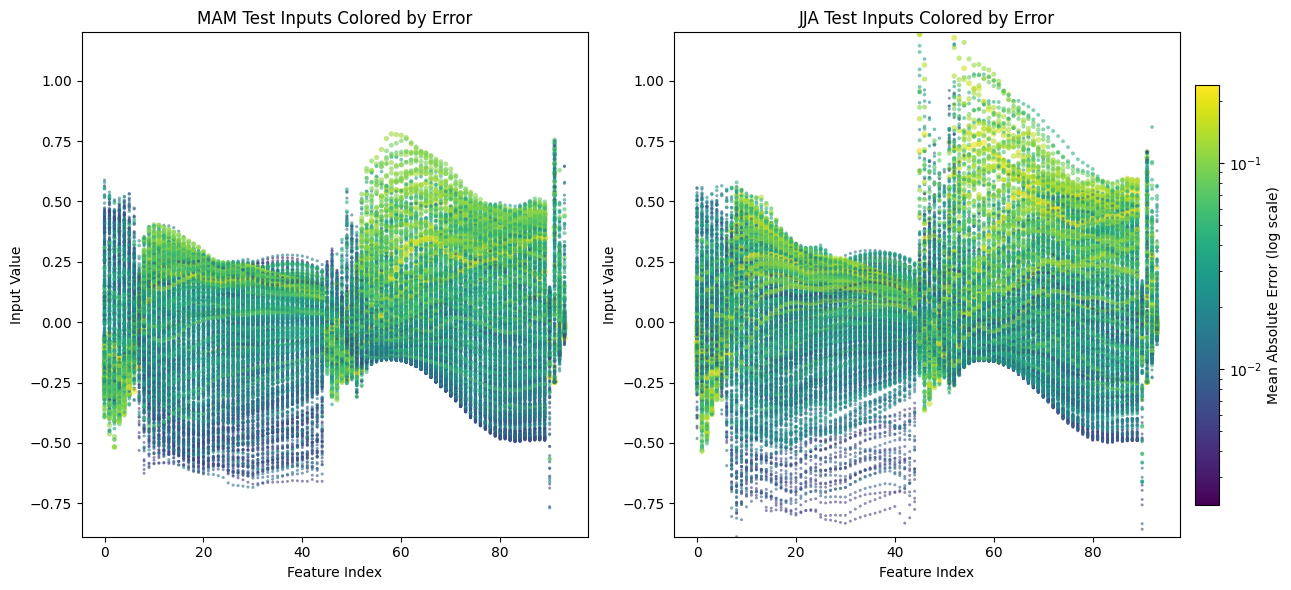

In [16]:
compare_input_distributions_by_error(vmin=None, vmax=1.2)


Ok nice, (after fixing the normalisation related issue) we can see that a. JJA contains plenty of values outside of the ranges of MAM and as expected these do carry high error. And you know what - I expect this, thats a normalisation issue in my point of view. What is interesting and perhaps still carries a glimmer of hope is the fact that it may be that JJA carries high error in areas that are 'in distribution' or at least, within the marginal distribution, which perhaps means there is occurences of composition or interpolation that I can take advantage of. So how do we look at this further? Well lets start with the idea I had before, looking at a slice of a variable and seeing how error is link. 

So the idea is for the same output, how much does the inputs vary, and is this linked to a. error and b. dataset. Lets start looking at a single variable 

5
5


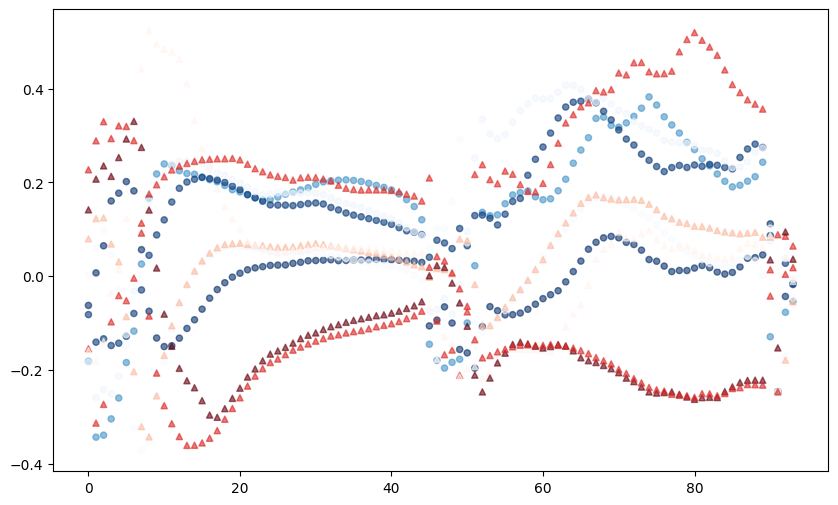

In [17]:
target_var = 74
min_target_value = -0.23
max_target_value = -0.20

# MAM test
mam_preds_var = mam_test['predictions'][:, target_var].cpu().numpy()
mam_targs_var = mam_test['targets'][:, target_var].cpu().numpy()
mask_mam = (mam_targs_var >= min_target_value) & (mam_targs_var <= max_target_value)
print(sum(mask_mam))

# JJA test
jja_preds_var = jja_test['predictions'][:, target_var].cpu().numpy()
jja_targs_var = jja_test['targets'][:, target_var].cpu().numpy()
mask_jja = (jja_targs_var >= min_target_value) & (jja_targs_var <= max_target_value)
print(sum(mask_jja))

# x axis is variable, y axis is value, color is error magnitude and shape is season (MAM vs JJA)
fig, ax = plt.subplots(figsize=(10, 6))

# MAM points
error_mam = np.abs(mam_preds_var - mam_targs_var)
error_mam_selected = error_mam[mask_mam]
inputs_mam_selected = reshape_to_standard_format(mam_test['inputs'])[mask_mam].cpu().numpy()
for feature_idx in range(inputs_mam_selected.shape[1]):
    inputs_feature = inputs_mam_selected[:, feature_idx]
    x = feature_idx * np.ones_like(inputs_feature)
    ax.scatter(x, inputs_feature, c=error_mam_selected, cmap='Blues', alpha=0.6, s=20, marker='o', label='MAM' if feature_idx == 0 else "")


# JJA points
error_jja = np.abs(jja_preds_var - jja_targs_var)
error_jja_selected = error_jja[mask_jja]
inputs_jja_selected = reshape_to_standard_format(jja_test['inputs'])[mask_jja].cpu().numpy()
for feature_idx in range(inputs_jja_selected.shape[1]):
    inputs_feature = inputs_jja_selected[:, feature_idx]
    x = feature_idx * np.ones_like(inputs_feature)
    ax.scatter(x, inputs_feature, c=error_jja_selected, cmap='Reds', alpha=0.6, s=20, marker='^', label='JJA' if feature_idx == 0 else "")

MAM selected: 5
JJA selected: 5
MAM errors: 0.08774676
JJA errors: 0.18917286


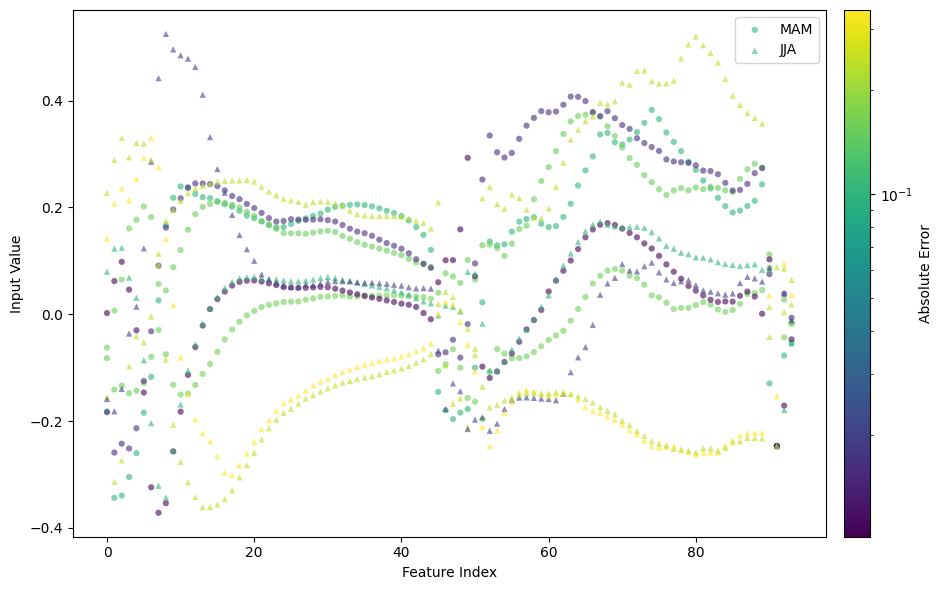

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

def plot_input_distributions_by_error(target_var = 74,
    min_target_value = -0.23,
    max_target_value = -0.20, vmax=None, vmin=None):
    

    # ======================
    # Extract data + masks
    # ======================
    mam_preds_var = mam_test['predictions'][:, target_var].cpu().numpy()
    mam_targs_var = mam_test['targets'][:, target_var].cpu().numpy()
    mask_mam = (mam_targs_var >= min_target_value) & (mam_targs_var <= max_target_value)

    jja_preds_var = jja_test['predictions'][:, target_var].cpu().numpy()
    jja_targs_var = jja_test['targets'][:, target_var].cpu().numpy()
    mask_jja = (jja_targs_var >= min_target_value) & (jja_targs_var <= max_target_value)

    print("MAM selected:", mask_mam.sum())
    print("JJA selected:", mask_jja.sum())

    # ======================
    # Errors (shared scale)
    # ======================
    error_mam = np.abs(mam_preds_var - mam_targs_var)[mask_mam]
    error_jja = np.abs(jja_preds_var - jja_targs_var)[mask_jja]
    print("MAM errors:", error_mam.mean())
    print("JJA errors:", error_jja.mean())

    all_errors = np.concatenate([error_mam, error_jja])

    norm = mpl.colors.LogNorm(
        vmin=all_errors.min(),
        vmax=all_errors.max()
    )

    cmap = plt.cm.viridis  # shared colormap

    # Error sized points 
    # Normalize errors for size scaling
    mam_size = 4 + 20 * (
        error_mam / error_mam.max()
    )

    jja_size = 4 + 20 * (
        error_jja / error_jja.max()
    )

    # ======================
    # Inputs
    # ======================
    inputs_mam = reshape_to_standard_format(mam_test['inputs'])[mask_mam].cpu().numpy()
    inputs_jja = reshape_to_standard_format(jja_test['inputs'])[mask_jja].cpu().numpy()

    # ======================
    # Plot
    # ======================
    fig, ax = plt.subplots(figsize=(10, 6))

    # --- MAM ---
    for feature_idx in range(inputs_mam.shape[1]):
        x = np.full(inputs_mam.shape[0], feature_idx)
        ax.scatter(
            x,
            inputs_mam[:, feature_idx],
            c=error_mam,
            cmap=cmap,
            norm=norm,
            s=20, #mam_size,
            linewidths=0,
            alpha=0.6,
            marker='o',
            label='MAM' if feature_idx == 0 else ""
        )

    # --- JJA ---
    for feature_idx in range(inputs_jja.shape[1]):
        x = np.full(inputs_jja.shape[0], feature_idx)
        ax.scatter(
            x,
            inputs_jja[:, feature_idx],
            c=error_jja,
            cmap=cmap,
            norm=norm,
            s=20, #jja_size,
            linewidths=0,
            alpha=0.6,
            marker='^',
            label='JJA' if feature_idx == 0 else ""
        )

    # ======================
    # Colorbar (shared)
    # ======================
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        pad=0.02
    )
    cbar.set_label('Absolute Error')

    # ======================
    # Labels
    # ======================
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Input Value')
    if vmax is not None and vmin is not None:
        ax.set_ylim(vmin, vmax)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_input_distributions_by_error()

MAM selected: 12
JJA selected: 18
MAM errors: 0.107788
JJA errors: 0.069109626


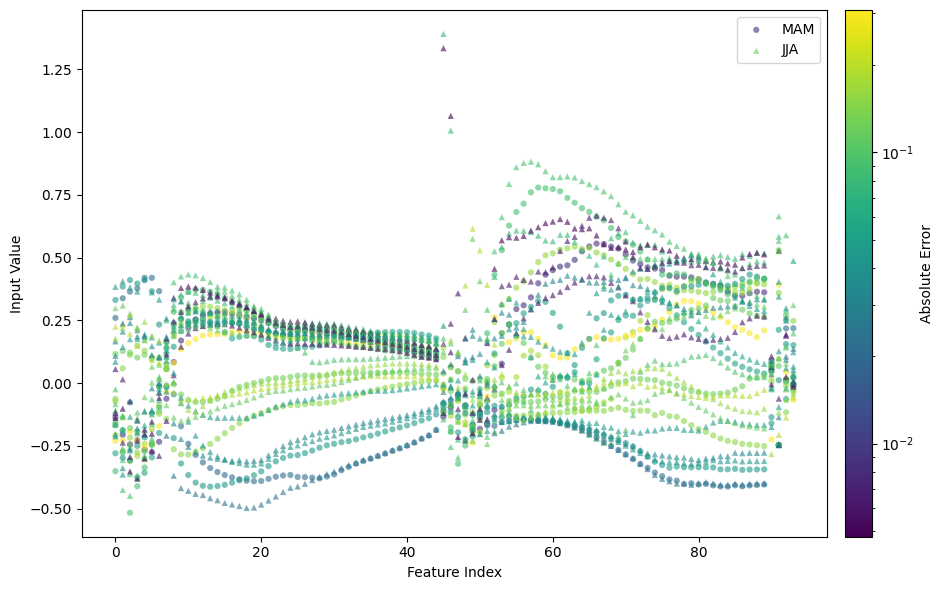

In [19]:
plot_input_distributions_by_error(target_var=44, min_target_value=-0.23, max_target_value=-0.20)

MAM selected: 766
JJA selected: 760
MAM errors: 0.04453312
JJA errors: 0.048358943


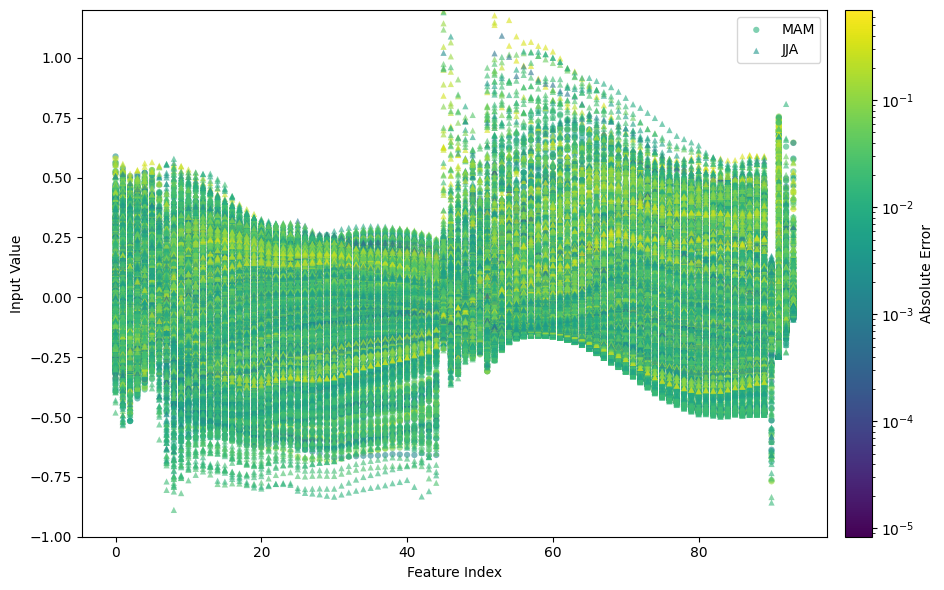

In [20]:
plot_input_distributions_by_error(target_var=96, min_target_value=0, max_target_value=1.2, vmax=1.2, vmin=-1)

Ok, these were not as useful as I would have hopped - they have made me think about spurious correlations perhaps causing these variations, or perhaps quantising to enforce the model to use a smaller set of values, anyway its not super clear that there is any key aspect I can try and target that differentiates tehe to distributions, apart from the obvious outliers ...

We are now going to try and look at 'explained marginals vs error' again starting high level this will be:
error on x-axis 
mean number of mam values that specific value is between.

JJA sample 0, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 1, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 2, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 3, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 4, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 5, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 6, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 7, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 8, feature 5, value -0.10269 -> 283 less, 485 greater, 1 equal in MAM (tol=1e-08).
JJA sample 8, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 9, feature 91, value -0.24665 -> 0 less,

JJA sample 648, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 649, feature 73, value -0.270149 -> 163 less, 605 greater, 1 equal in MAM (tol=1e-08).
JJA sample 649, feature 76, value -0.307491 -> 144 less, 624 greater, 1 equal in MAM (tol=1e-08).
JJA sample 649, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 650, feature 57, value -0.14689 -> 66 less, 702 greater, 1 equal in MAM (tol=1e-08).
JJA sample 650, feature 71, value -0.247612 -> 149 less, 619 greater, 1 equal in MAM (tol=1e-08).
JJA sample 650, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 651, feature 60, value -0.156415 -> 33 less, 735 greater, 1 equal in MAM (tol=1e-08).
JJA sample 651, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 652, feature 91, value -0.24665 -> 0 less, 394 greater, 374 equal in MAM (tol=1e-08).
JJA sample 653, feature 91, 

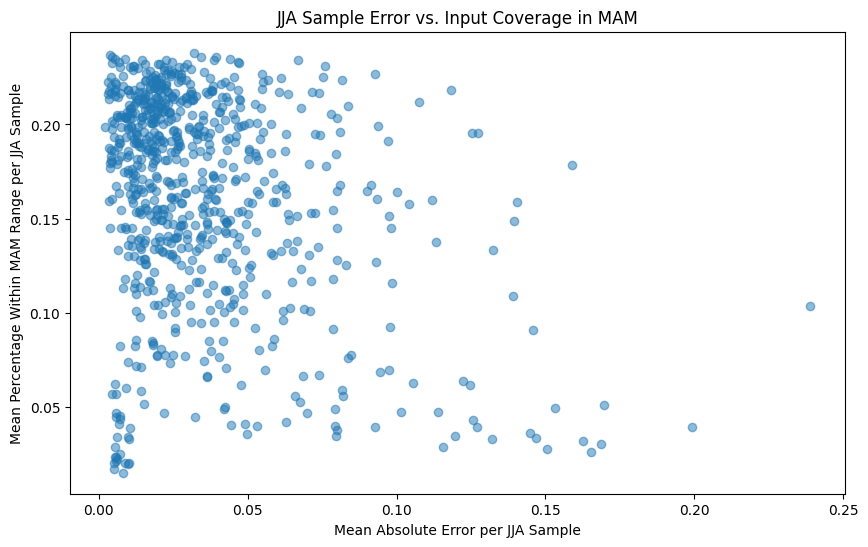

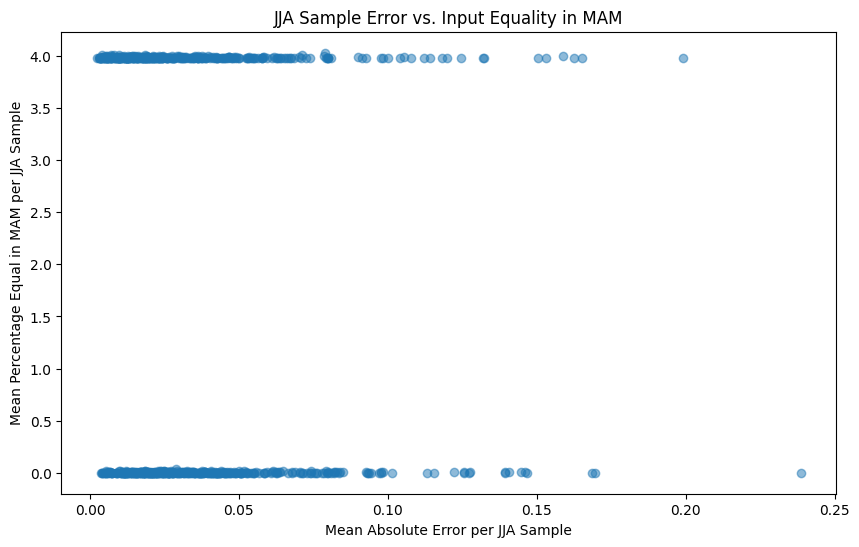

In [21]:
import numpy as np

# Ensure numpy arrays
jja_test_input = reshape_to_standard_format(jja_test['inputs']).cpu().numpy()
mam_test_input = reshape_to_standard_format(mam_test['inputs']).cpu().numpy()

# Get errors
jja_test_error = torch.abs(jja_test['predictions'] - jja_test['targets']).mean(dim=1).cpu().numpy()

n_jja, n_features = jja_test_input.shape
n_mam = mam_test_input.shape[0]

tol = 1e-8  # tolerance for float equality, adjust if needed

percentage_within_list = []
percentage_equal_list = []
for i in range(n_jja):
    sample = jja_test_input[i]
    feature_within_list = []
    feature_equal_list = []
    for j in range(n_features):
        val = sample[j]
        col = mam_test_input[:, j]            # correct: column j
        number_less_than = np.sum(col < val)
        number_greater_than = np.sum(col > val)
        number_equal = np.sum(np.isclose(col, val, atol=tol))

        if number_equal > 0:
            print(f"JJA sample {i}, feature {j}, value {val:.6g} -> "
                  f"{number_less_than} less, {number_greater_than} greater, "
                  f"{number_equal} equal in MAM (tol={tol}).")
        percentage_within = (number_less_than / n_mam) * (number_greater_than / n_mam)
        feature_within_list.append(percentage_within)
        feature_equal_list.append(number_equal)
    percentage_within_list.append(feature_within_list)
    percentage_equal_list.append(feature_equal_list)

percentage_within_array = np.array(percentage_within_list).reshape(n_jja, n_features)
percentage_equal_array = np.array(percentage_equal_list).reshape(n_jja, n_features)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(jja_test_error, percentage_within_array.mean(axis=1), 'o', alpha=0.5)
ax.set_xlabel('Mean Absolute Error per JJA Sample')
ax.set_ylabel('Mean Percentage Within MAM Range per JJA Sample')
ax.set_title('JJA Sample Error vs. Input Coverage in MAM')
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(jja_test_error, percentage_equal_array.mean(axis=1), 'o', alpha=0.5)
ax.set_xlabel('Mean Absolute Error per JJA Sample')
ax.set_ylabel('Mean Percentage Equal in MAM per JJA Sample')
ax.set_title('JJA Sample Error vs. Input Equality in MAM')
plt.show()


JJA sample 20, feature 0, value -0.0720247 -> 384 less, 383 greater, 1 equal in MAM (tol=1e-05).
JJA sample 28, feature 0, value 0.000874948 -> 449 less, 318 greater, 1 equal in MAM (tol=1e-05).
JJA sample 36, feature 0, value -0.0710834 -> 387 less, 380 greater, 1 equal in MAM (tol=1e-05).
JJA sample 40, feature 0, value -0.0733849 -> 379 less, 388 greater, 1 equal in MAM (tol=1e-05).
JJA sample 65, feature 0, value 0.117986 -> 545 less, 222 greater, 1 equal in MAM (tol=1e-05).
JJA sample 152, feature 1, value -0.343272 -> 42 less, 725 greater, 1 equal in MAM (tol=1e-05).
JJA sample 273, feature 1, value 0.0915428 -> 479 less, 288 greater, 1 equal in MAM (tol=1e-05).
JJA sample 290, feature 1, value 0.121637 -> 512 less, 255 greater, 1 equal in MAM (tol=1e-05).
JJA sample 305, feature 1, value 0.12768 -> 517 less, 250 greater, 1 equal in MAM (tol=1e-05).
JJA sample 373, feature 1, value 0.438236 -> 727 less, 40 greater, 1 equal in MAM (tol=1e-05).
JJA sample 98, feature 2, value -0.25

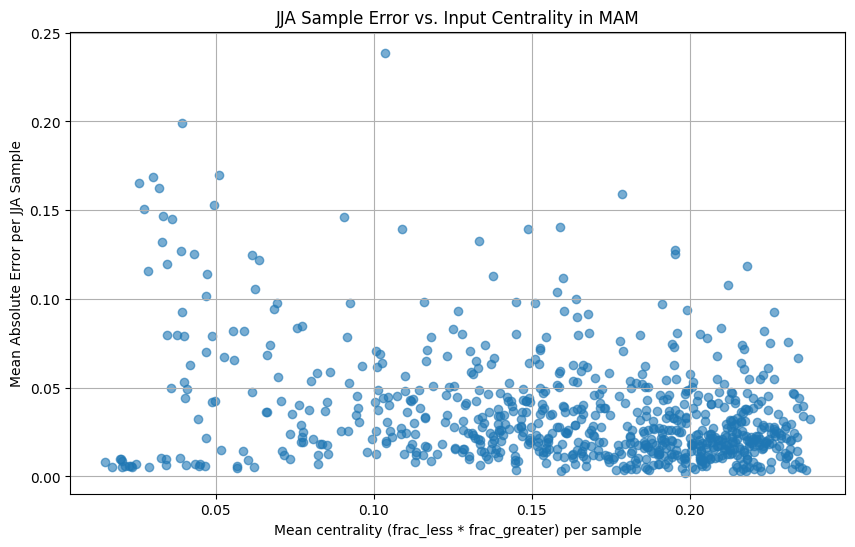

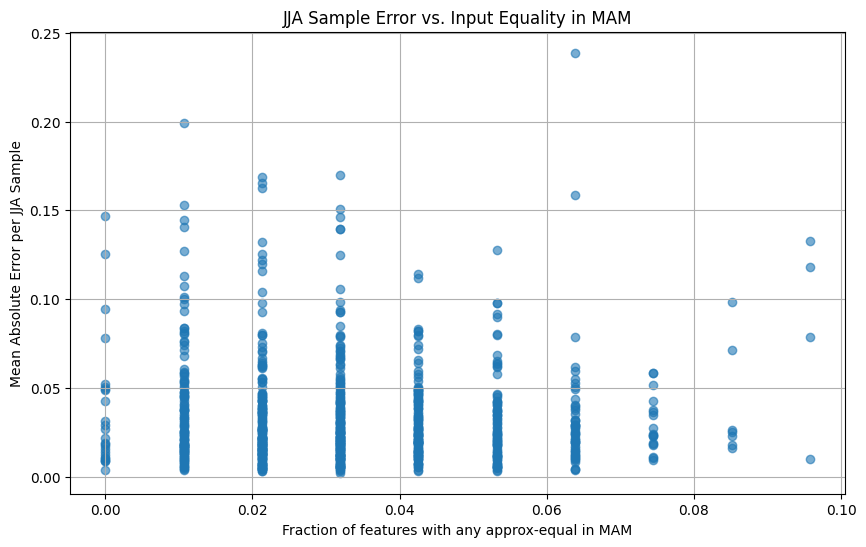

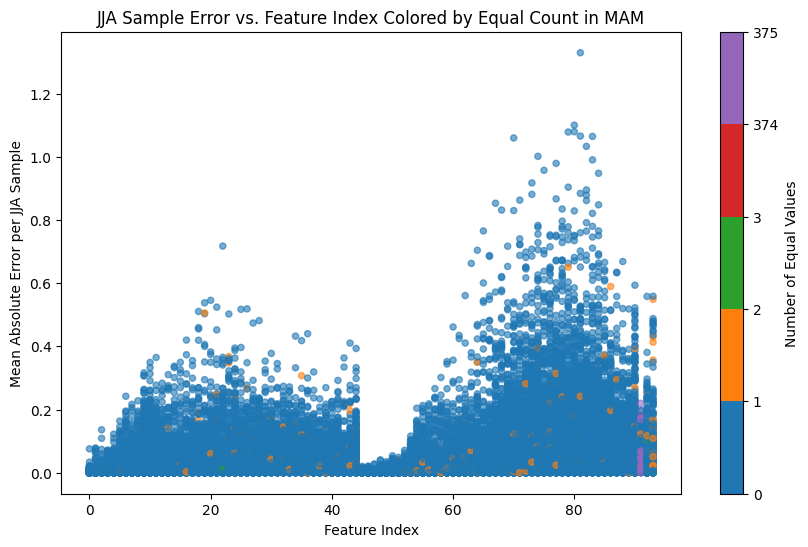

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def compare_jja_to_mam(
    jja_test, mam_test,
    reshape_to_standard_format,
    tol: float = 1e-0
):
    """
    Compare JJA input samples against MAM input distribution per-feature.
    Returns:
      jja_error: numpy array, shape (n_jja,)
      percentage_within_array: numpy array, shape (n_jja, n_features)
          (here defined as (frac_less * frac_greater) per feature)
      equal_counts_array: numpy array, shape (n_jja, n_features)
          number of MAM samples that are approximately equal to the JJA value
    """
    # Convert inputs to numpy arrays (ensure correct shapes)
    jja_test_input = reshape_to_standard_format(jja_test['inputs']).cpu().numpy()
    mam_test_input = reshape_to_standard_format(mam_test['inputs']).cpu().numpy()

    # JJA error: ensure 1D array with same length as jja_test_input
    jja_test_error = torch.abs(jja_test['predictions'] - jja_test['targets']).mean(dim=1).cpu().numpy().ravel()

    n_jja, n_features = jja_test_input.shape
    n_mam = mam_test_input.shape[0]

    # Preallocate outputs
    percentage_within_array = np.empty((n_jja, n_features), dtype=float)
    equal_counts_array = np.empty((n_jja, n_features), dtype=int)

    # For each feature: sort the MAM values once, then use searchsorted for all jja samples
    for j in range(n_features):
        col = mam_test_input[:, j]
        col_sorted = np.sort(col)  # ascending

        # values to compare: all JJA sample values for feature j
        vals = jja_test_input[:, j]

        # For tolerance: treat values within [val - tol, val + tol] as equal
        left_bounds = vals - tol
        right_bounds = vals + tol

        # left index = number strictly less than (val - tol) + number within range?
        # We'll compute:
        # number_less = index of first element >= (val - tol)  => searchsorted(left_bounds, side='left')
        # number_eq = searchsorted(right_bounds, 'right') - searchsorted(left_bounds, 'left')
        # number_greater = n_mam - (number_less + number_eq)
        left_idx = np.searchsorted(col_sorted, left_bounds, side='left')   # count of elements < left_bound
        right_idx = np.searchsorted(col_sorted, right_bounds, side='right') # count of elements <= right_bound

        number_equal = right_idx - left_idx
        number_less = left_idx
        number_greater = n_mam - right_idx

        # store
        equal_counts_array[:, j] = number_equal
        # fraction less and fraction greater
        frac_less = number_less.astype(float) / n_mam
        frac_greater = number_greater.astype(float) / n_mam

        # Keep the original idea: product of the two fractions. This is highest when
        # frac_less ≈ frac_greater ≈ 0.5 (i.e. value is central in MAM distribution).
        percentage_within_array[:, j] = frac_less * frac_greater

        # Optional: log examples where equal > 0 (keeps behavior from original)
        # Print at most first few to avoid overwhelming logs
        eq_mask = number_equal > 0
        if np.any(eq_mask):
            idxs = np.nonzero(eq_mask)[0]
            # print up to first 5 equal occurrences per feature
            for ii in idxs[:5]:
                val = vals[ii]
                nl = number_less[ii]
                ng = number_greater[ii]
                ne = number_equal[ii]
                print(f"JJA sample {ii}, feature {j}, value {val:.6g} -> "
                      f"{nl} less, {ng} greater, {ne} equal in MAM (tol={tol}).")

    return jja_test_error, percentage_within_array, equal_counts_array


# -----------------------
# Example usage (run in your environment)
# -----------------------
jja_error, pct_within, equal_counts = compare_jja_to_mam(
    jja_test=jja_test,
    mam_test=mam_test,
    reshape_to_standard_format=reshape_to_standard_format,
    tol=1e-5
)

# Aggregate per-sample means for plotting
mean_pct_within_per_sample = pct_within.mean(axis=1)
mean_equal_count_per_sample = (equal_counts > 0).mean(axis=1)  # fraction of features with any equal
# or use equal_counts.mean(axis=1) to plot average equal count per sample

# Plot: Error vs centrality (product-of-fracs)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mean_pct_within_per_sample, jja_error, alpha=0.6)
ax.set_ylabel('Mean Absolute Error per JJA Sample')
ax.set_xlabel('Mean centrality (frac_less * frac_greater) per sample')
ax.set_title('JJA Sample Error vs. Input Centrality in MAM')
ax.grid(True)
plt.show()

# Plot: Error vs equality presence
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(mean_equal_count_per_sample, jja_error, alpha=0.6)
ax.set_ylabel('Mean Absolute Error per JJA Sample')
ax.set_xlabel('Fraction of features with any approx-equal in MAM')
ax.set_title('JJA Sample Error vs. Input Equality in MAM')
ax.grid(True)
plt.show()

jja_error = torch.abs(jja_test['predictions'] - jja_test['targets'])

import matplotlib.colors as mcolors

unique_counts = np.unique(equal_counts)
cmap = plt.cm.tab10
norm = mcolors.BoundaryNorm(
    boundaries=np.append(unique_counts, unique_counts[-1] + 1),
    ncolors=len(unique_counts)
)


fig, ax = plt.subplots(figsize=(10, 6))
for i in range(equal_counts.shape[1]):
    x = i * np.ones_like(equal_counts[:, i])
    ax.scatter(x, jja_error[:, i], c=equal_counts[:, i], cmap=cmap, norm=norm, alpha=0.6, s=20)
ax.set_xlabel('Feature Index')
ax.set_ylabel('Mean Absolute Error per JJA Sample')
ax.set_title('JJA Sample Error vs. Feature Index Colored by Equal Count in MAM')

cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax
)
cbar.set_label('Number of Equal Values')

In [23]:
sum(equal_counts)

array([    19,     10,     14,     14,     14,     23,     20,     22,
            9,     16,     20,     16,     17,      8,     13,     14,
           13,     10,     15,     15,     18,     21,     20,     11,
           18,     19,     18,     29,     22,     22,     21,     23,
           29,     29,     28,     21,     27,     32,     30,     30,
           29,     26,     29,     24,     34,     38,     30,     23,
           27,     25,     30,     21,     18,     18,     28,     29,
           27,     50,     52,     44,     46,     34,     29,     32,
           23,     29,     25,     15,     17,     21,     15,     17,
           14,     13,     11,      6,     14,     15,      8,     11,
           14,     11,     10,     13,      9,     13,      8,      6,
           14,     18,     31, 140630,     46,    138])

Ok ok, not majorly usefull, but, I would argue two things:
1. the more 'surrounded' a sample is the better (more in distribution in some sense)
2. the more of the same points the better

i.e Hypothesis: if we can enforce our model to reuse values as much as possible but still have a largenough latent space to carry 'high f' components, we should achieve lower error. 

I think one way to test this is:

model each sample as a point in 'high dimensional space' find its nearest neighbour to the MAM dataset hold the distance value and plot distance against error - my hypothesis being - the smaller the distance the lower the error. 

We should then also do a check to see if there is a relationship between distance and true value or something like this.

The point of all of this being - if I can force my model to have to use the same values more frequently, litearlly giving it a smaller possible vocablary then perhaps I can enforce future values to be put in with things it has already seen?? 

In [24]:
mam_test_input.shape

(768, 94)

(768, 2)
(768, 2)


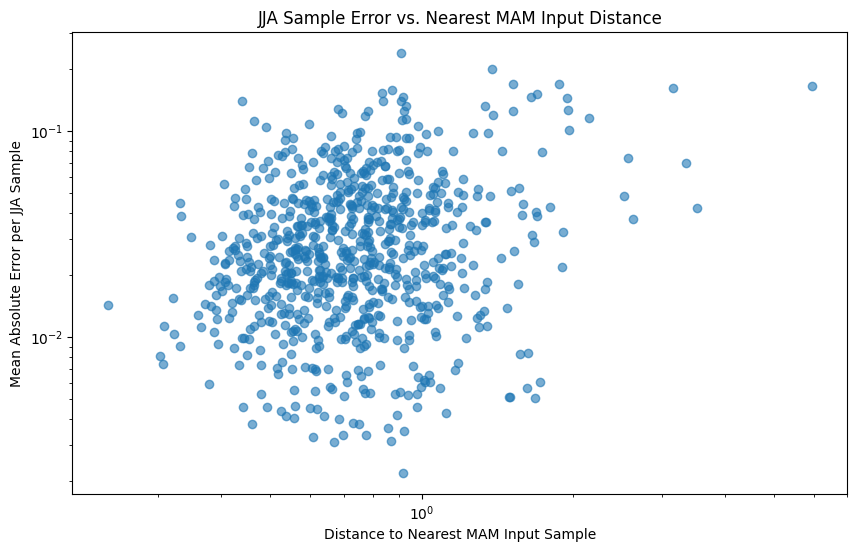

In [25]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=2, algorithm='kd_tree').fit(mam_test_input)
distances, indices = nbrs.kneighbors(jja_test_input)

print(distances.shape)  # should be (n_jja, 2)
print(indices.shape)   # should be (n_jja, 2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(distances[:, 0], jja_test_error, alpha=0.6)
ax.set_xlabel('Distance to Nearest MAM Input Sample')
ax.set_ylabel('Mean Absolute Error per JJA Sample')
ax.set_title('JJA Sample Error vs. Nearest MAM Input Distance')
ax.set_xscale('log')  # 👈 make x-axis logarithmic
ax.set_yscale('log')  # 👈 make y-axis logarithmic
plt.show()

hmm, ok there clearly isnt a relationship here - but hey thats a win in its own way

Text(0.5, 1.0, 'JJA Targets vs Nearest MAM Targets')

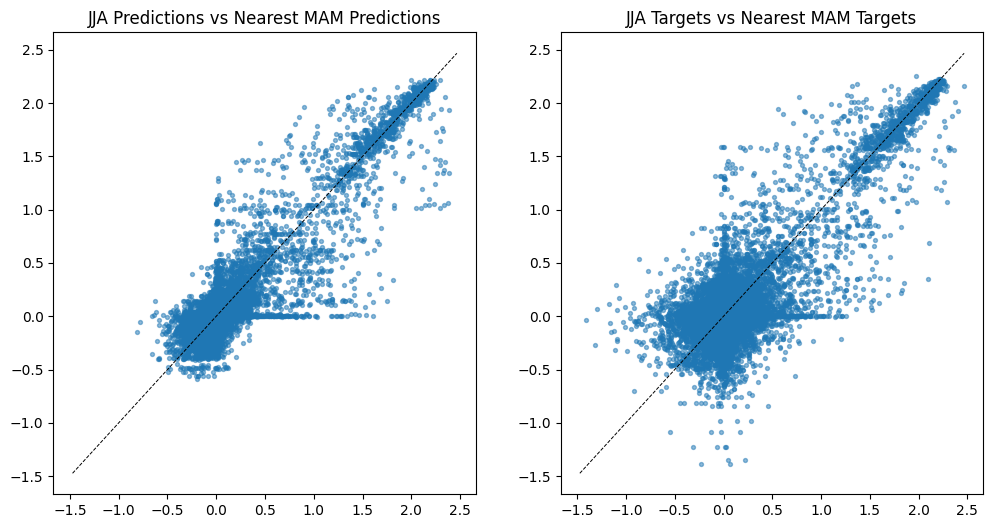

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

x_max = max(jja_test['predictions'].max(), jja_test['targets'].max()).item()
x_min = min(jja_test['predictions'].min(), jja_test['targets'].min()).item()
y_max = max(mam_test['predictions'].max(), mam_test['targets'].max()).item()
y_min = min(mam_test['predictions'].min(), mam_test['targets'].min()).item()

hi = max(x_max, y_max)
lo = min(x_min, y_min)


# pred vs pred 
ax = axes[0]
ax.scatter(jja_test['predictions'].cpu().numpy(), mam_test['predictions'][indices[:, 0]].cpu().numpy(), alpha=0.5, s=8)
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
ax.set_title('JJA Predictions vs Nearest MAM Predictions')

# targ vs targ
ax = axes[1]
ax.scatter(jja_test['targets'].cpu().numpy(), mam_test['targets'][indices[:, 0]].cpu().numpy(), alpha=0.5, s=8)
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
ax.set_title('JJA Targets vs Nearest MAM Targets')

Ok so this plot is kinda confusing. We use KNN to find the closest point in MAM based on the input values. For each sample JJA output value (be it predicted (left) or true (right)) we plot it against the output value of the MAM sample its closest too. So basically, 

for the left plot:
- if close to y=x then the model's 'inernals' have a similar process and we find that it predicts based off similarity (we dont know if this is good or not!)
- if far apart, the model does not try and fit points together 

for the right plot:
- if close to y=x, we can safely say that the 'closer together points' within the input space result in simar values in the output space 
- if far apart, then there the knn is nonsense

if left is more y=x than the right -> our model is relying on this relationship too much when it isnt true 
if the other way around, there is a utlisation that has not yet been taken advantage off.

So to conclude this kinda goes against my results as it seems like this is missing a bunch of information. 

But I have some more questions:

1. How does this relate to model error?
2. Is this true for inter datasets?

I am rushed and the relation to error is not super promising - I was hoping to see that error increase with distance from y=x - but this is not clear. Maybe there is something here, maybe not - this has been a good dive into the data tho so well done. My current conclusions are mixed:
- Right now I feel latent space alignment doesnt actually make much sense - I think tho, I need more evidence before making such conclusions 
- I like this idea which is very related of confining possible set of values, yet I am grasping on thin air for evidence of this to work at all but I do think there is something their towards small improvements. 
- I think we should continue by asking the questions above, then following this train of thought for as long as there is hope, then trying to move back to the spatial alignment / invariance. Then maybe back to sparsity ... which is kinda all trying to do a similar thing. 

In [27]:
# jja_error = torch.abs(jja_test['predictions'] - jja_test['targets']).mean(dim=1)
# # jja_error = jja_error.unsqueeze(1).repeat(1, 98)

# norm = mpl.colors.Normalize(
#         vmin=jja_error.min(),
#         vmax=jja_error.max()
#     )

# cmap = plt.cm.viridis # shared colormap

# fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# x_max = max(jja_test['predictions'].max(), jja_test['targets'].max()).item()
# x_min = min(jja_test['predictions'].min(), jja_test['targets'].min()).item()
# y_max = max(mam_test['predictions'].max(), mam_test['targets'].max()).item()
# y_min = min(mam_test['predictions'].min(), mam_test['targets'].min()).item()

# hi = max(x_max, y_max)
# lo = min(x_min, y_min)

# # pred vs pred 
# ax = axes[0]
# ax.scatter(jja_test['predictions'][:,74].cpu().numpy(), mam_test['predictions'][indices[:, 0]][:, 74].cpu().numpy(), c=jja_error.cpu().numpy(), alpha=0.5, s=5, linewidths=0)
# ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
# ax.set_title('JJA Predictions vs Nearest MAM Predictions')

# # targ vs targ
# ax = axes[1]
# ax.scatter(jja_test['targets'].cpu().numpy(), mam_test['targets'][indices[:, 0]].cpu().numpy(), c=jja_error.cpu().numpy(), alpha=0.5, s=5, linewidths=0)
# ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
# ax.set_title('JJA Targets vs Nearest MAM Targets')

# cax = fig.add_axes([1, 0.15, 0.02, 0.7])

# cbar = fig.colorbar(
#     mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
#     cax=cax
# )
# cbar.set_label('Absolute Error')

# plt.show

In [28]:
# import torch
# import matplotlib as mpl
# import matplotlib.pyplot as plt

# # compute per-sample absolute error (1D)
# jja_error = torch.abs(jja_test['predictions'] - jja_test['targets']).mean(dim=1)  # shape (N,)

# # If you truly need an (N,98) array elsewhere, create it there.
# # For plotting, use the 1D per-sample error:
# jja_error_1d = jja_error.detach().cpu().numpy()   # shape (N,)

# # colormap normalization (use floats)
# norm = mpl.colors.Normalize(vmin=float(jja_error.min().item()), vmax=float(jja_error.max().item()))
# cmap = plt.cm.viridis

# fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# # compute common axis limits (convert to scalars)
# x_max = float(jja_test['predictions'].max().item())
# x_min = float(jja_test['predictions'].min().item())
# y_max = float(mam_test['predictions'].max().item())
# y_min = float(mam_test['predictions'].min().item())

# hi = max(x_max, y_max)
# lo = min(x_min, y_min)

# # first scatter: JJA preds vs nearest MAM preds
# ax = axes[0]
# ax.scatter(
#     jja_test['predictions'].flatten().detach().cpu().numpy().ravel(),                     # or [:,col] depending how you want to plot
#     mam_test['predictions'][indices[:, 0]].flatten().detach().cpu().numpy().ravel(),
#     c=jja_error_1d,
#     cmap=cmap,
#     norm=norm,
#     alpha=0.5,
#     s=5,
#     linewidths=0
# )
# ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
# ax.set_title('JJA Predictions vs Nearest MAM Predictions')

# # second scatter: JJA targets vs nearest MAM targets
# ax = axes[1]
# ax.scatter(
#     jja_test['targets'].flatten().detach().cpu().numpy().ravel(),
#     mam_test['targets'][indices[:, 0]].flatten().detach().cpu().numpy().ravel(),
#     c=jja_error_1d,
#     cmap=cmap,
#     norm=norm,
#     alpha=0.5,
#     s=5,
#     linewidths=0
# )
# ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
# ax.set_title('JJA Targets vs Nearest MAM Targets')

# # colorbar - let matplotlib place it nicely
# fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes.ravel().tolist(), fraction=0.02, pad=0.02).set_label('Absolute Error')

# plt.tight_layout()
# plt.show()


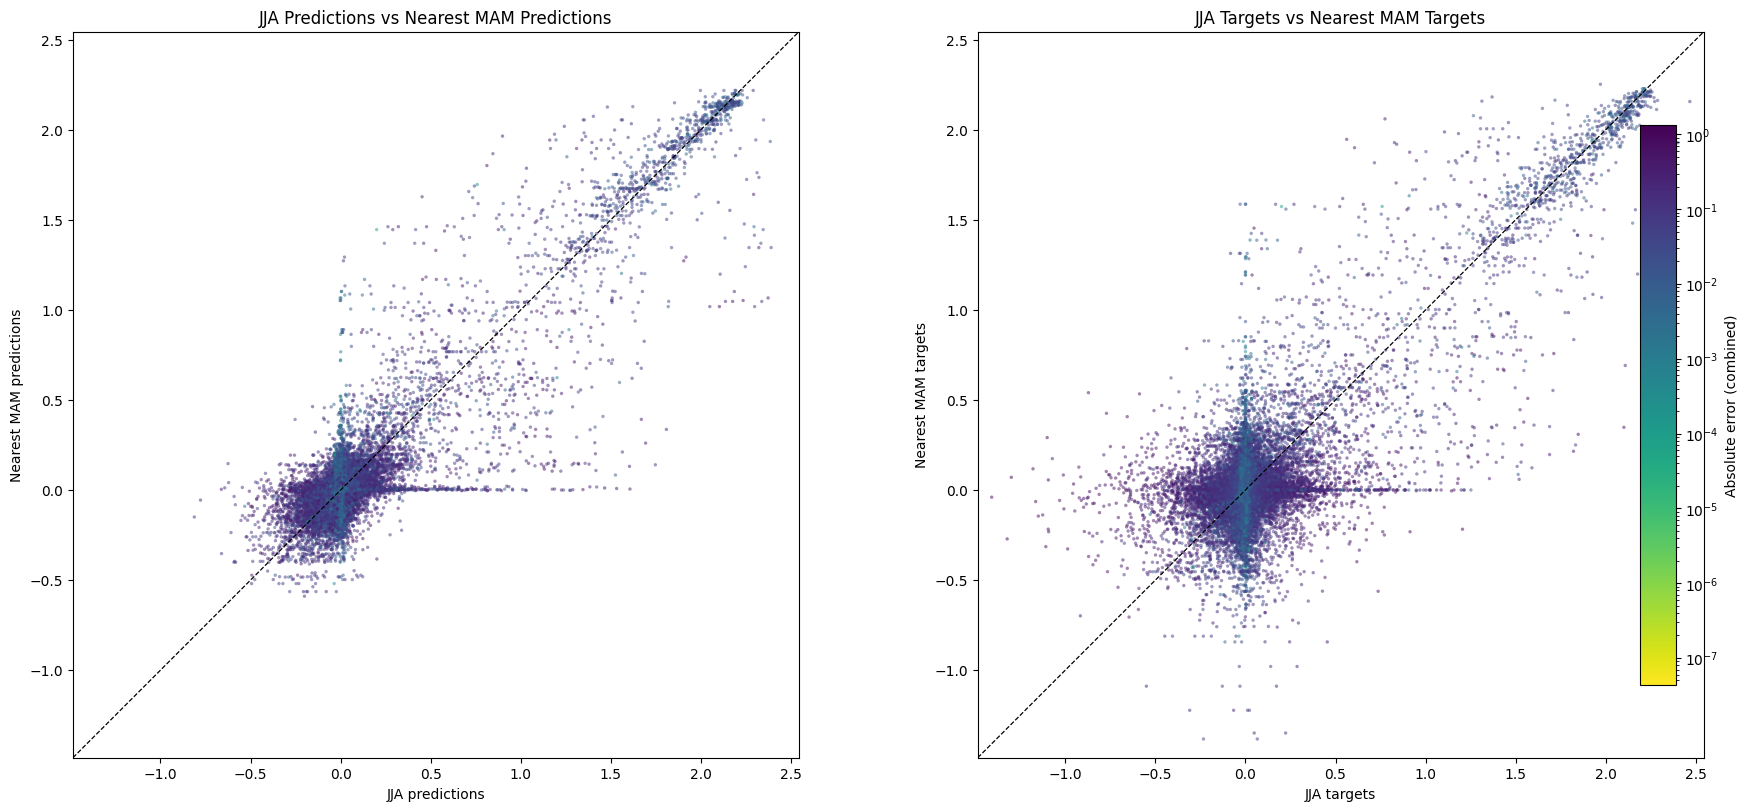

In [29]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch

# --- prepare data (make sure tensors are on cpu and flattened) ---
jja_pred = jja_test['predictions'].detach().cpu().ravel().numpy()
jja_targ = jja_test['targets'].detach().cpu().ravel().numpy()
mam_pred = mam_test['predictions'].detach().cpu().numpy()
mam_targ = mam_test['targets'].detach().cpu().numpy()

# indices -> nearest MAM indices (ensure on cpu and int)
idx = indices[:, 0].astype(np.int64)

mam_pred_near = mam_pred[idx].ravel()
mam_targ_near = mam_targ[idx].ravel()

# compute errors
jja_error = np.abs(jja_pred - jja_targ)
mam_error_at_nearest = np.abs(mam_pred_near - mam_targ_near)  # or as you need

# If you want to color by the JJA absolute error vs. nearest-MAM predictions/targets:
color_err_pred = jja_error        # color for pred vs pred plot
color_err_targ = jja_error        # color for targ vs targ plot (or use combined below)

# OR create a combined error (e.g. max or mean) to color both subplots consistently:
combined_error = jja_error # np.maximum(jja_error, mam_error_at_nearest)

# --- choose colormap and norm safely ---
cmap = plt.cm.viridis_r

# If you want a log-color scale, ensure vmin > 0. Otherwise fall back to linear Normalize.
min_pos = combined_error[combined_error > 0].min() if np.any(combined_error > 0) else 1e-8
vmin_log = max(min_pos, 1e-8)
vmax = combined_error.max()

use_log = True  # toggle if you prefer log scaling
if use_log and vmin_log > 0 and vmax / vmin_log > 100:  # only use log when dynamic range is large
    norm = mpl.colors.LogNorm(vmin=vmin_log, vmax=vmax)
else:
    norm = mpl.colors.Normalize(vmin=combined_error.min(), vmax=vmax)

# --- plotting ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# compute shared axis limits so diagonal line is meaningful
all_vals = np.concatenate([jja_pred, jja_targ, mam_pred_near, mam_targ_near])
lo = float(np.nanmin(all_vals))
hi = float(np.nanmax(all_vals))
pad = 0.02 * (hi - lo)
lo -= pad
hi += pad

# PLOT 1: JJA predictions vs nearest MAM predictions
ax = axes[0]
sc1 = ax.scatter(jja_pred, mam_pred_near, c=combined_error, cmap=cmap, norm=norm,
                 s=6, alpha=0.5, edgecolors='none', marker='o')
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.9)
ax.set_title('JJA Predictions vs Nearest MAM Predictions')
ax.set_xlabel('JJA predictions')
ax.set_ylabel('Nearest MAM predictions')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', 'box')

# PLOT 2: JJA targets vs nearest MAM targets
ax = axes[1]
sc2 = ax.scatter(jja_targ, mam_targ_near, c=combined_error, cmap=cmap, norm=norm,
                 s=6, alpha=0.5, edgecolors='none', marker='o')
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.9)
ax.set_title('JJA Targets vs Nearest MAM Targets')
ax.set_xlabel('JJA targets')
ax.set_ylabel('Nearest MAM targets')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal', 'box')

# colorbar: use a ScalarMappable with same norm/cmap
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(combined_error)   # avoids Matplotlib warning about empty mappable
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Absolute error (combined)')

plt.show()


In [30]:
print(min(distances[:, 0]))
print(distances.shape)
print(max(distances[:, 0]))

0.23784952206595547
(768, 2)
5.962450856116156


In [42]:
import numpy as np

small_distances = distances[:, 0] > 1
print(int(np.sum(small_distances)))

# ensure a copy so we don't modify original unexpectedly
dummy_predictions = jja_test['predictions'].clone()

idx = np.asarray(indices[:, 0])[small_distances]          # integer positions
dummy_predictions[small_distances] = mam_test['predictions'][idx]

mam_mse_as_jja = torch.mean((
    dummy_predictions - jja_test['targets']
)**2).item()
print(mam_mse_as_jja)

# 0.006423135753720999 0
# 0.006441982928663492 1
# 0.006441099103540182 3
# 0.0064514754340052605 4


134
0.008162128739058971


Ok, so I am looking for some relationship between forcing inputs of JJA similar to MAM to output the same value, but nothing is very solid. The above experiement aims to select based off distances and assign those to MAM predictions that are similar in the input space. Replacing ones that are very small immediately makes things worse, but replacing ones that are very large does have small levels of improvement. There is still a lot! of potential factors that could be either making this not true or making it true, one for example is the distance metric I am using. 

So I am thinking there is a bunch of other options:


2. Make my own distance metric?

So what would this be - distance in each dimension scaled meaned together 

In [ ]:
print(jja_test['inputs'].shape)
nvar = reshape_to_standard_format(jja_test['inputs']).shape[1]

for var in range(nvar):
    jja_vals = reshape_to_standard_format(jja_test['inputs'])[:, var]
    mam_vals = reshape_to_standard_format(mam_test['inputs'])[:, var]

    for jja_idx in range(jja_vals.shape[0]):
        for mam_idx in range(mam_vals.shape[0]):
            if torch.allclose(jja_vals[jja_idx], mam_vals[mam_idx], atol=1e-8):
                print(f"JJA sample {jja_idx} feature {var} matches MAM sample {mam_idx} value {jja_vals[jja_idx].item()}")

torch.Size([768, 45, 6])
  JJA min/max: -0.481241 / 0.556375
  MAM min/max: -0.39386 / 0.588372
  JJA min/max: -0.534187 / 0.557701
  MAM min/max: -0.462616 / 0.538308
  JJA min/max: -0.502543 / 0.516703
  MAM min/max: -0.516826 / 0.506595
  JJA min/max: -0.381948 / 0.531878
  MAM min/max: -0.422365 / 0.513247
  JJA min/max: -0.3209 / 0.560186
  MAM min/max: -0.384991 / 0.520228
  JJA min/max: -0.380054 / 0.564793
  MAM min/max: -0.341979 / 0.531824
  JJA min/max: -0.593739 / 0.55008
  MAM min/max: -0.323816 / 0.472759
  JJA min/max: -0.804405 / 0.557476
  MAM min/max: -0.530777 / 0.336996
  JJA min/max: -0.888031 / 0.578595
  MAM min/max: -0.625292 / 0.355359
  JJA min/max: -0.817723 / 0.548697
  MAM min/max: -0.602145 / 0.396106
  JJA min/max: -0.764207 / 0.534131
  MAM min/max: -0.585832 / 0.403386
  JJA min/max: -0.741521 / 0.522058
  MAM min/max: -0.583505 / 0.401529
  JJA min/max: -0.727358 / 0.515911
  MAM min/max: -0.582552 / 0.401004
  JJA min/max: -0.740012 / 0.516579
  MAM m

(768, 2)
(768, 2)


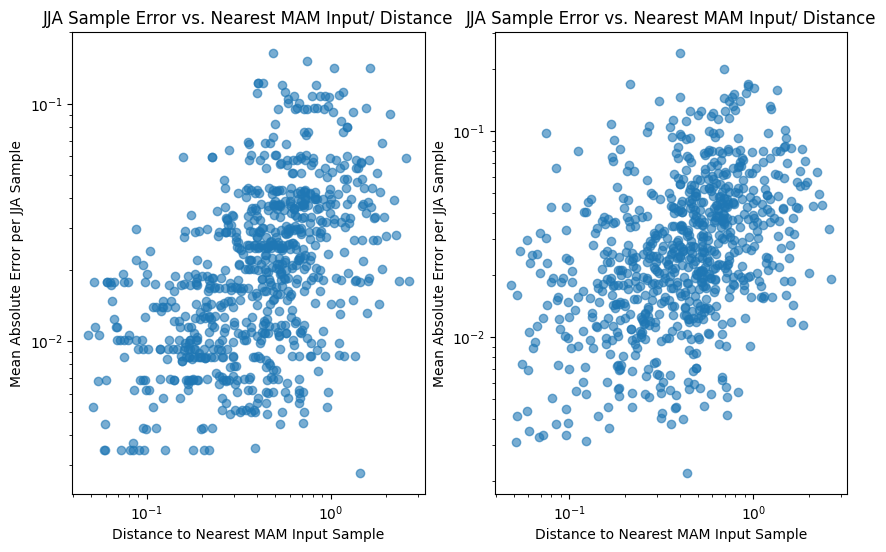

In [55]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=2, algorithm='kd_tree').fit(jja_test['targets'].cpu().numpy())
distances, indices = nbrs.kneighbors(mam_test['targets'].cpu().numpy())

mam_test_error = torch.abs(mam_test['predictions'] - mam_test['targets']).mean(dim=1).cpu().numpy()
jja_test_error = torch.abs(jja_test['predictions'] - jja_test['targets']).mean(dim=1).cpu().numpy()


print(distances.shape)  # should be (n_jja, 2)
print(indices.shape)   # should be (n_jja, 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
ax = axes[0]
ax.scatter(distances[:, 0], mam_test_error[indices[:, 0]], alpha=0.6)
ax.set_xlabel('Distance to Nearest MAM Input Sample')
ax.set_ylabel('Mean Absolute Error per JJA Sample')
ax.set_title('JJA Sample Error vs. Nearest MAM Input/ Distance')
ax.set_xscale('log')  # 👈 make x-axis logarithmic
ax.set_yscale('log')  # 👈 make y-axis logarithmic

ax = axes[1]
ax.scatter(distances[:, 0], jja_test_error, alpha=0.6)
ax.set_xlabel('Distance to Nearest MAM Input Sample')
ax.set_ylabel('Mean Absolute Error per JJA Sample')
ax.set_title('JJA Sample Error vs. Nearest MAM Input/ Distance')
ax.set_xscale('log')  # 👈 make x-axis logarithmic
ax.set_yscale('log')  # 👈 make y-axis logarithmic

plt.show()

Ok, sadly its pretty clear that this distance metric stuff isn't very helpful. And I think I need to keep understanding the code. One thing that has caught my interest now is the when looking at 'amount of data a sample is within' we see a very approximate correlation, and a bunch of 'high' withins that still have mid performance ... . Perhaps this is the area that I should try and understand why these are failing. Also this notebook has got too long, so I will start another one.